# Markov-kæder / Markov Chains

**Kursus / Course:** DM887 — Reinforcement Learning, SDU  
**Forelæsning / Lecture:** 3 — Mannor Book Chapter 4  
**Emne / Topic:** Markov-kæder, tilstandsklassifikation, stationære fordelinger, ergodisk teori  
**Topic:** Markov chains, state classification, stationary distributions, ergodic theory

## Ordliste / Glossary — Fagudtryk i dagligsprog

> Disse ord bruges overalt i notebooken. Her er hvad de **faktisk** betyder, uden det formelle.

| Fagudtryk | Engelsk | Hvad det betyder i dagligsprog |
|-----------|---------|-------------------------------|
| **Transient** | Transient | En tilstand du **forlader for altid** paa et tidspunkt. Taenk paa en lufthavn du flyver igennem: du kommer der maaske en gang, men du vender aldrig tilbage. |
| **Rekurrent** | Recurrent | En tilstand du **altid vender tilbage til**, uanset hvad. Din seng derhjemme — du forlader den, men du ender altid med at komme tilbage. |
| **Konvergens** | Convergence | Naar noget **naermer sig en fast vaerdi** og til sidst "lander". Taenk paa at haelde vand i et badekar — vandstanden stiger, men den stopper ved et fast niveau naar det loeber over. |
| **Stationaer fordeling** | Stationary distribution | Den faste "ligevaegt" som systemet ender i. Hvis 2/3 af dagene er sol og 1/3 er regn i det lange loeb — det er den stationaere fordeling. |
| **Ergodisk** | Ergodic | Kaedens "one-size-fits-all" egenskab: **uanset hvor du starter**, ender du med det samme resultat paa lang sigt. Alle veje foerer til Rom. |
| **Periodisk** | Periodic | En tilstand du kun kan vende tilbage til med faste mellemrum. Taenk paa en uge: du kan kun vaere paa "mandag" hver 7. dag, aldrig hver 3. |
| **Aperiodisk** | Aperiodic | Du kan vende tilbage **naar som helst** — ingen fast rytme. De fleste hverdags-systemer er aperiodiske. |
| **Kommunikerende** | Communicating | To tilstande der kan **naa hinanden**. Hvis du kan kore fra Odense til Koebenhavn OG fra Koebenhavn til Odense, kommunikerer de. |
| **Irreducibel** | Irreducible | **Alle** tilstande kan naa hinanden. Hele systemet haenger sammen — ingen isolerede oeer. |
| **Reducibel** | Reducible | Systemet har isolerede grupper. Nogle tilstande kan **ikke** naa andre — der er "oeer" der ikke har baad imellem sig. |
| **Absorbing** | Absorbing | En tilstand du **aldrig forlader** naar du foerst er der. Et sort hul — alt der kommer ind, bliver der. |
| **Mixing time** | Mixing time | Hvor **hurtigt** kaeden "glemmer" hvor den startede og begynder at ligne ligevaegten. Kort mixing time = hurtig konvergens. |
| **Detailed balance** | Detailed balance | Trafikken er **lige stor begge veje** mellem alle par af tilstande. Lige saa mange korer Odense→KBH som KBH→Odense. |
| **Potensmatrix** ($P^m$) | Power matrix | Overgangsmatricen ganget med sig selv $m$ gange — giver sandsynlighederne for at naa fra A til B i praecis $m$ trin. |
| **Self-loop** | Self-loop | En pil fra en tilstand **til sig selv** — sandsynligheden for at **blive** hvor du er. |

## 1. Definition af Markov-kæder / Definition of Markov Chains

**DK:** En Markov-kæde $\{X_t, t = 0, 1, 2, \ldots\}$ med $X_t \in \mathcal{X}$ er en diskret-tids stokastisk proces over et endeligt eller tælleligt tilstandsrum $\mathcal{X}$, der opfylder **Markov-egenskaben**: fremtiden afhænger kun af nutiden, ikke af fortiden.

**EN:** A Markov chain $\{X_t, t = 0, 1, 2, \ldots\}$ with $X_t \in \mathcal{X}$ is a discrete-time stochastic process over a finite or countable state space $\mathcal{X}$ that satisfies the **Markov property**: the future depends only on the present, not on the past.

### Markov-egenskaben / The Markov Property

$$\Pr(X_{t+1} = j \mid X_t = i, X_{t-1}, \ldots, X_0) = \Pr(X_{t+1} = j \mid X_t = i)$$

### Tidshomogen Markov-kæde / Time-Homogeneous Markov Chain

$$\Pr(X_{t+1} = j \mid X_t = i) = \Pr(X_1 = j \mid X_0 = i) \stackrel{\Delta}{=} p_{i,j}$$

| Symbol | Navn (DK) | Name (EN) | Betydning |
|--------|-----------|-----------|-----------|
| $X_t \in \mathcal{X}$ | Tilstand ved tid $t$ | State at time $t$ | Kædens tilstand på tidspunkt $t$ |
| $p_{i,j}$ | Overgangssandsynlighed | Transition probability | $\Pr(X_{t+1}=j \mid X_t=i)$ |
| $P = (p_{i,j})$ | Overgangsmatrix | Transition matrix | Rækkestokastisk matrix ($\sum_j p_{i,j} = 1$) |
| $p_0$ | Startfordeling | Initial distribution | $\Pr(X_0 = i) = p_0(i)$ |

### Fællesfordeling / Joint Distribution

$$\Pr(X_0 = i_0, X_1 = i_1, \ldots, X_t = i_t) = p_0(i_0) \cdot p_{i_0, i_1} \cdot \ldots \cdot p_{i_{t-1}, i_t}$$

**DK:** Den fulde fordeling af kædens bane bestemmes altså af startfordelingen $p_0$ og overgangsmatricen $P$.

**EN:** The full distribution of the chain's trajectory is thus determined by the initial distribution $p_0$ and the transition matrix $P$.

## 2. Fler-trins overgangssandsynligheder / Multi-Step Transition Probabilities

**DK:** Vi kan beregne sandsynligheden for at gå fra tilstand $i$ til tilstand $j$ i præcis $m$ trin ved at opløfte overgangsmatricen $P$ til $m$-te potens.

**EN:** We can compute the probability of going from state $i$ to state $j$ in exactly $m$ steps by raising the transition matrix $P$ to the $m$-th power.

### $m$-trins overgangssandsynlighed / $m$-step transition probability

$$p_{i,j}^{(m)} = \Pr(X_m = j \mid X_0 = i) = [P^m]_{ij}$$

### Fordeling efter $t$ trin / Distribution after $t$ steps

$$p_t = p_0 \cdot P^t$$

**DK:** Hvis startfordelingen er $p_0$, er fordelingen efter $t$ trin givet ved $p_0 P^t$. Vi multiplicerer blot startfordelingen med overgangsmatricen gentagne gange.

**EN:** If the initial distribution is $p_0$, the distribution after $t$ steps is given by $p_0 P^t$. We simply multiply the initial distribution by the transition matrix repeatedly.

### Eksempel fra bogen / Textbook Example (Example 4.1)

$$P = \begin{pmatrix} 0.4 & 0.6 \\ 0.2 & 0.8 \end{pmatrix}, \quad p_0 = (0.5, 0.5)$$

$$p_1 = p_0 P = (0.3, 0.7), \quad p_2 = p_0 P^2 = (0.26, 0.74), \quad p_\infty = (0.25, 0.75)$$

**DK:** Fordelingen konvergerer mod en **stationær fordeling** $\mu$ — dette er kernen i den ergodiske teori, som vi dækker i sektion 6.

**EN:** The distribution converges to a **stationary distribution** $\mu$ — this is the core of ergodic theory, covered in section 6.

## 3. Tilstandsklassifikation / State Classification

**DK:** Vi klassificerer tilstande i en Markov-kæde ud fra, om de kan nå hinanden. Dette giver os begreberne tilgængelighed, kommunikerende klasser og irreducibilitet.

**EN:** We classify states in a Markov chain based on whether they can reach each other. This gives us the concepts of accessibility, communicating classes, and irreducibility.

### Definition 4.1 — Tilgængelighed / Accessibility

**DK:** Tilstand $j$ er **tilgængelig** (reachable) fra $i$ (skrevet $i \to j$) hvis $p_{i,j}^{(m)} > 0$ for et $m \geq 1$.

**EN:** State $j$ is **accessible** from $i$ (written $i \to j$) if $p_{i,j}^{(m)} > 0$ for some $m \geq 1$.

> **Graffortolkning:** Konstruér en rettet graf $G(\mathcal{X}, E)$ hvor der er en kant $(i, j)$ hvis $p_{i,j} > 0$. Så er $j$ tilgængelig fra $i$ præcis hvis der findes en rettet sti fra $i$ til $j$.

### Kommunikerende tilstande / Communicating States

**DK:** Tilstande $i$ og $j$ **kommunikerer** hvis $i \to j$ og $j \to i$. Relationen er transitiv: $i \to j$ og $j \to k$ medfører $i \to k$.

**EN:** States $i$ and $j$ **communicate** if $i \to j$ and $j \to i$. The relation is transitive: $i \to j$ and $j \to k$ implies $i \to k$.

### Definition 4.2 — Kommunikerende klasser / Communicating Classes

**DK:** En **kommunikerende klasse** er en maksimal samling af tilstande der alle kommunikerer med hinanden. Svarer til **stærkt sammenhængende komponenter** i den rettede graf.

**EN:** A **communicating class** is a maximal collection of states that all communicate with each other. Corresponds to **strongly connected components** in the directed graph.

### Definition 4.3 — Irreducibilitet / Irreducibility

**DK:** Markov-kæden er **irreducibel** hvis alle tilstande tilhører én enkelt klasse (dvs. alle tilstande kommunikerer med hinanden). Grafen $G(\mathcal{X}, E)$ er stærkt sammenhængende.

**EN:** The Markov chain is **irreducible** if all states belong to a single class (i.e., all states communicate). The graph $G(\mathcal{X}, E)$ is strongly connected.

## 4. Periodicitet / Periodicity

**DK:** Periodicitet beskriver, om en tilstand kun kan genbesøges i faste intervaller. En tilstand med periode 2 kan f.eks. kun genbesøges efter et lige antal trin.

**EN:** Periodicity describes whether a state can only be revisited at fixed intervals. A state with period 2 can, e.g., only be revisited after an even number of steps.

### Definition 4.4 — Periode / Period

$$d_i = \text{GCD}\{m \geq 1 : p_{i,i}^{(m)} > 0\}$$

**DK:** Perioden $d_i$ er den **største fælles divisor** af alle returlængder til tilstand $i$. En tilstand er **aperiodisk** hvis $d_i = 1$.

**EN:** The period $d_i$ is the **greatest common divisor** of all return lengths to state $i$. A state is **aperiodic** if $d_i = 1$.

### Nøgleegenskaber / Key Properties

| Egenskab (DK) | Property (EN) | Forklaring |
|---------------|---------------|------------|
| Periodicitet er en klasseegenskab | Periodicity is a class property | Alle tilstande i samme klasse har samme periode / All states in the same class have the same period |
| Aperiodisk ⟹ alle aperiodiske | Aperiodic ⟹ all aperiodic | Hvis én tilstand i klassen er aperiodisk, er alle det |
| Selv-løkke ⟹ $d_i = 1$ | Self-loop ⟹ $d_i = 1$ | $p_{i,i} > 0$ giver $\text{GCD}$ indeholder 1, altså aperiodisk |

**Claim 4.1:** For to tilstande $i, j$ i samme kommunikerende klasse gælder $d_i = d_j$.

**DK:** *Bevis-idé:* Antag $d_j \nmid d_i$. Da der er en sti fra $i$ til $j$ (længde $m_{i,j}$) og fra $j$ til $i$ (længde $m_{j,i}$), kan man konstruere en cyklus fra $i$ med længde $m_{i,j} + m_{j,j} + m_{j,i}$ som ikke er delelig med $d_i$ — modstrid.

**EN:** *Proof idea:* Assume $d_j \nmid d_i$. Since there is a path from $i$ to $j$ (length $m_{i,j}$) and from $j$ to $i$ (length $m_{j,i}$), one can construct a cycle from $i$ of length $m_{i,j} + m_{j,j} + m_{j,i}$ that is not divisible by $d_i$ — contradiction.

## 5. Rekurrens / Recurrence

**DK:** En tilstand er **rekurrent** hvis Markov-kæden med sikkerhed vender tilbage til den. Ellers er tilstanden **transient** — kæden forlader den til sidst for altid.

**EN:** A state is **recurrent** if the Markov chain returns to it with certainty. Otherwise, the state is **transient** — the chain eventually leaves it forever.

### Definition 4.5 — Rekurrent og Transient / Recurrent and Transient

$$\text{Tilstand } i \text{ er rekurrent} \iff \Pr(X_t = i \text{ for et } t \geq 1 \mid X_0 = i) = 1$$

$$\text{State } i \text{ is recurrent} \iff \Pr(X_t = i \text{ for some } t \geq 1 \mid X_0 = i) = 1$$

### Claim 4.2 — Karakterisering via summen / Characterization via the Sum

$$\text{Tilstand } i \text{ er transient} \iff \sum_{m=1}^{\infty} p_{i,i}^{(m)} < \infty$$

**DK:** Hvis summen af retursandsynligheder er endelig, forventer vi et endeligt antal besøg — altså er tilstanden transient. Er summen uendelig, vender kæden altid tilbage — tilstanden er rekurrent.

**EN:** If the sum of return probabilities is finite, we expect a finite number of visits — so the state is transient. If the sum is infinite, the chain always returns — the state is recurrent.

### Positiv vs. Nul-rekurrent / Positive vs. Null Recurrent

| Type | Betingelse / Condition | Fortolkning |
|------|----------------------|-------------|
| **Positiv rekurrent** | $E[T_i] < \infty$ | Forventet returtid er endelig / Expected return time is finite |
| **Nul-rekurrent** | $E[T_i] = \infty$, men kæden vender stadig altid tilbage | Kæden returnerer, men returtiden er uendelig i gennemsnit / Chain returns but mean return time is infinite |
| **Transient** | $\Pr(\text{retur}) < 1$ | Kæden vender måske aldrig tilbage / Chain may never return |

hvor $T_i = \min\{t \geq 1 : X_t = i\}$ er **returtiden** til tilstand $i$.

### Claim 4.3 — Rekurrens er en klasseegenskab / Recurrence is a Class Property

**DK:** Alle tilstande i en kommunikerende klasse er enten alle rekurrente eller alle transiente. For endelige tilstandsrum gælder: mindst én klasse er rekurrent.

**EN:** All states in a communicating class are either all recurrent or all transient. For finite state spaces: at least one class is recurrent.

## 6. Stationær fordeling og ergodisk teori / Stationary Distribution & Ergodic Theory

**DK:** En **invariant (stationær) fordeling** $\mu$ er en fordeling der ikke ændres af overgangsmatricen: $\mu^\top P = \mu^\top$. For irreducible aperiodiske kæder konvergerer fordelingen altid mod $\mu$.

**EN:** An **invariant (stationary) distribution** $\mu$ is a distribution unchanged by the transition matrix: $\mu^\top P = \mu^\top$. For irreducible aperiodic chains, the distribution always converges to $\mu$.

### Theorem 4.7 — Eksistens og entydighed / Existence and Uniqueness

**DK:** For en **irreducibel**, **aperiodisk**, **endelig** Markov-kæde eksisterer en entydig stationær fordeling $\mu > 0$ med $\mu^\top P = \mu^\top$.

**EN:** For an **irreducible**, **aperiodic**, **finite** Markov chain, there exists a unique stationary distribution $\mu > 0$ with $\mu^\top P = \mu^\top$.

### Theorem 4.8 — Sammenhæng med returtid / Connection to Return Time

$$\mu_j = \frac{1}{E[T_j]}$$

**DK:** Den stationære sandsynlighed for tilstand $j$ er den inverse forventede returtid. Hyppigt besøgte tilstande har høj stationær sandsynlighed.

**EN:** The stationary probability of state $j$ is the inverse of the expected return time. Frequently visited states have high stationary probability.

### Theorem 4.9 — Ergodisk sætning / Ergodic Theorem

For en irreducibel Markov-kæde over et endeligt tilstandsrum gælder:

1. Alle tilstande er **positivt rekurrente** / All states are **positive recurrent**
2. Der eksisterer en entydig stationær fordeling $\mu$ / A unique stationary distribution $\mu$ exists  
3. **Konvergens:** $\lim_{t \to \infty} \Pr(X_t = j) = \mu_j \quad (\forall j)$ (for aperiodiske kæder)
4. **Tidsmiddel:** $\lim_{t \to \infty} \frac{1}{t} \sum_{s=0}^{t-1} f(X_s) = \sum_i \mu_i f(i)$ med sandsynlighed 1

**DK:** Punkt (4) er den **ergodiske sætning**: tidsgennemsnittet af enhver funktion $f$ konvergerer mod det vægtede gennemsnit under $\mu$. Det er analogt med "store tals lov" for Markov-kæder.

**EN:** Point (4) is the **ergodic theorem**: the time-average of any function $f$ converges to the weighted average under $\mu$. This is analogous to the "law of large numbers" for Markov chains.

### Theorem 4.10 — Tællelige Markov-kæder / Countable Markov Chains

**DK:** For en irreducibel kæde over et **tælleligt** tilstandsrum er præcis én af følgende sande: (i) alle tilstande er positivt rekurrente, (ii) alle er nul-rekurrente, (iii) alle er transiente.

**EN:** For an irreducible chain over a **countable** state space, exactly one of the following holds: (i) all states are positive recurrent, (ii) all are null recurrent, (iii) all are transient.

## 7. Reversible Markov-kæder og detaljeret balance / Reversible Markov Chains & Detailed Balance

**DK:** En Markov-kæde er **reversibel** hvis der eksisterer en fordeling $\mu$ der opfylder **detaljeret balance** — sandsynlighedsstrømmen mellem ethvert par af tilstande er den samme i begge retninger.

**EN:** A Markov chain is **reversible** if there exists a distribution $\mu$ that satisfies **detailed balance** — the probability flow between any pair of states is the same in both directions.

### Detaljeret balance-ligninger / Detailed Balance Equations

$$\mu_i \, p_{i,j} = \mu_j \, p_{j,i}, \quad \forall \, i, j \in \mathcal{X}$$

**DK:** Hvis $\mu$ opfylder detaljeret balance, er $\mu$ automatisk en invariant fordeling:

**EN:** If $\mu$ satisfies detailed balance, then $\mu$ is automatically an invariant distribution:

$$\sum_i \mu_i \, p_{i,j} = \sum_i \mu_j \, p_{j,i} = \mu_j \sum_i p_{j,i} = \mu_j$$

### Hvorfor er det vigtigt? / Why does this matter?

**DK:** Detaljeret balance giver en nem metode til at *finde* den stationære fordeling — i stedet for at løse $\mu^\top P = \mu^\top$ direkte, kan man ofte gætte $\mu$ og verificere balance-ligningerne.

**EN:** Detailed balance provides an easy method to *find* the stationary distribution — instead of solving $\mu^\top P = \mu^\top$ directly, one can often guess $\mu$ and verify the balance equations.

> **Eksempler:** Fødsel-død-processer, køsystemer, fysiske systemer i ligevægt (Boltzmann-fordeling), og MCMC-metoder (Metropolis-Hastings) er alle baseret på reversibilitet.

---

## Eksempel 1: To-tilstands vejrmodel / Example 1: Two-State Weather Model

**DK:** En simpel vejrmodel med to tilstande: **Sol** (S) og **Regn** (R). Overgangssandsynlighederne er:

**EN:** A simple weather model with two states: **Sun** (S) and **Rain** (R). The transition probabilities are:

| Fra / From | Til Sol / To Sun | Til Regn / To Rain |
|------------|-----------------|-------------------|
| **Sol / Sun** | 0.8 | 0.2 |
| **Regn / Rain** | 0.4 | 0.6 |

$$P = \begin{pmatrix} 0.8 & 0.2 \\ 0.4 & 0.6 \end{pmatrix}, \quad p_0 = (1, 0) \text{ (starter med sol / starts with sun)}$$

**Spørgsmål / Questions:**
1. Hvad er fordelingen efter 1, 2, 5, 10 trin? / What is the distribution after 1, 2, 5, 10 steps?
2. Hvad er den stationære fordeling? / What is the stationary distribution?

### Visuel oversigt / Visual Overview

```mermaid
stateDiagram-v2
    Sol --> Sol : 0.8
    Sol --> Regn : 0.2
    Regn --> Sol : 0.4
    Regn --> Regn : 0.6
```

#### Graph-visning / Graph view

```mermaid
graph LR
    Sol(("Sol / Sun")) -->|0.8| Sol
    Sol -->|0.2| Regn(("Regn / Rain"))
    Regn -->|0.4| Sol
    Regn -->|0.6| Regn
```

### LaTeX tilstandsdiagram / LaTeX state diagram

$$
\begin{array}{ccc}
 & \xrightarrow{\quad 0.2 \quad} & \\[-4pt]
\boxed{\textbf{Sol}} & & \boxed{\textbf{Regn}} \\[-4pt]
 & \xleftarrow{\quad 0.4 \quad} & \\[6pt]
{\scriptstyle 0.8}\;\circlearrowleft & & \circlearrowright\;{\scriptstyle 0.6}
\end{array}
$$

**Overgangsmatrix / Transition matrix:**

$$P = \begin{pmatrix} 0.8 & 0.2 \\ 0.4 & 0.6 \end{pmatrix}, \quad \mathcal{X} = \{\text{Sol}, \text{Regn}\}$$

**DK:** Sol-tilstanden er mere "klistret" (0.8 selv-loekke) end Regn (0.6), saa vi forventer, at den stationaere fordeling favoriserer sol.

**EN:** The Sun state is more "sticky" (0.8 self-loop) than Rain (0.6), so we expect the stationary distribution to favor sun.

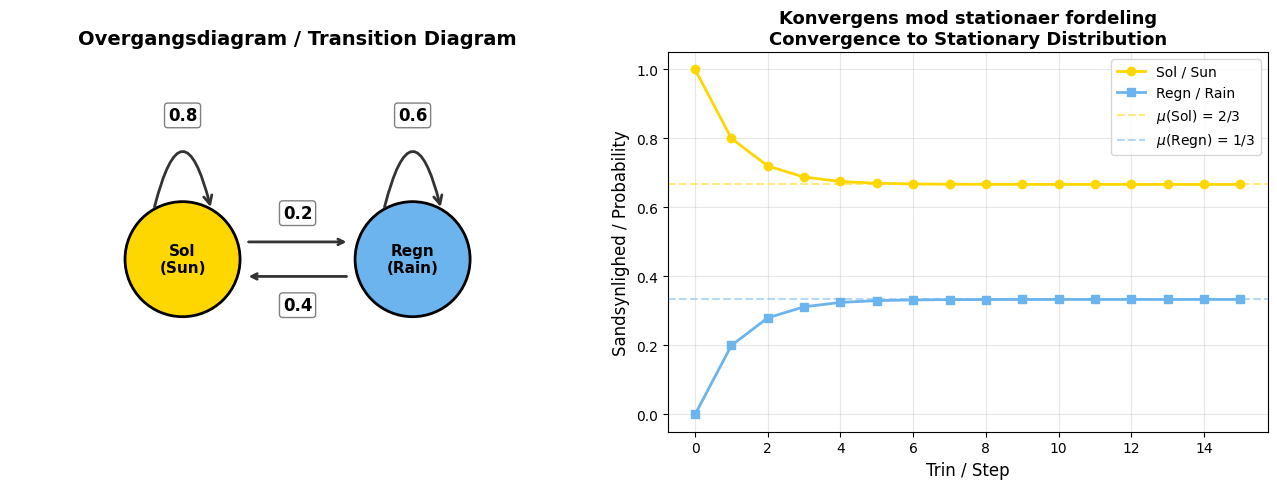

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- Example 1: Two-State Weather Chain - State Diagram ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: State transition diagram
ax1.set_xlim(-1.5, 3.5)
ax1.set_ylim(-1.5, 1.8)
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title('Overgangsdiagram / Transition Diagram', fontsize=14, fontweight='bold')

for (x, y, label, color) in [(0, 0, 'Sol\n(Sun)', '#FFD700'), (2, 0, 'Regn\n(Rain)', '#6CB4EE')]:
    circle = plt.Circle((x, y), 0.5, fill=True, facecolor=color, edgecolor='black', linewidth=2)
    ax1.add_patch(circle)
    ax1.text(x, y, label, ha='center', va='center', fontsize=11, fontweight='bold')

# Self-loops
arc_sol = mpatches.FancyArrowPatch((-0.25, 0.43), (0.25, 0.43),
                                    connectionstyle="arc3,rad=-2.0",
                                    arrowstyle='->', mutation_scale=15, lw=2, color='#333')
ax1.add_patch(arc_sol)
ax1.text(0.0, 1.25, '0.8', ha='center', va='center', fontsize=12,
         fontweight='bold', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='gray'))

arc_regn = mpatches.FancyArrowPatch((1.75, 0.43), (2.25, 0.43),
                                     connectionstyle="arc3,rad=-2.0",
                                     arrowstyle='->', mutation_scale=15, lw=2, color='#333')
ax1.add_patch(arc_regn)
ax1.text(2.0, 1.25, '0.6', ha='center', va='center', fontsize=12,
         fontweight='bold', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='gray'))

# Transition arrows
ax1.annotate('', xy=(1.45, 0.15), xytext=(0.55, 0.15),
             arrowprops=dict(arrowstyle='->', lw=2, color='#333'))
ax1.text(1, 0.4, '0.2', ha='center', va='center', fontsize=12, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='gray'))

ax1.annotate('', xy=(0.55, -0.15), xytext=(1.45, -0.15),
             arrowprops=dict(arrowstyle='->', lw=2, color='#333'))
ax1.text(1, -0.4, '0.4', ha='center', va='center', fontsize=12, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='gray'))

# Right: Distribution convergence
P = np.array([[0.8, 0.2],
              [0.4, 0.6]])
p = np.array([1.0, 0.0])  # start with Sun
steps = 15
distributions = [p.copy()]
for t in range(steps):
    p = p @ P
    distributions.append(p.copy())

distributions = np.array(distributions)
ax2.plot(range(steps+1), distributions[:, 0], 'o-', color='#FFD700', linewidth=2, markersize=6, label='Sol / Sun')
ax2.plot(range(steps+1), distributions[:, 1], 's-', color='#6CB4EE', linewidth=2, markersize=6, label='Regn / Rain')
ax2.axhline(y=2/3, color='#FFD700', linestyle='--', alpha=0.5, label=f'$\\mu$(Sol) = 2/3')
ax2.axhline(y=1/3, color='#6CB4EE', linestyle='--', alpha=0.5, label=f'$\\mu$(Regn) = 1/3')
ax2.set_xlabel('Trin / Step', fontsize=12)
ax2.set_ylabel('Sandsynlighed / Probability', fontsize=12)
ax2.set_title('Konvergens mod stationaer fordeling\nConvergence to Stationary Distribution', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.set_ylim(-0.05, 1.05)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Symbolforklaring / Symbol Guide

| Symbol | Navn | Betydning |
|--------|------|-----------|
| $P$ | **Overgangsmatrix** / Transition matrix | En matrix hvor indgang $P_{ij}$ er sandsynligheden for at gaa fra tilstand $i$ til tilstand $j$. Hver raekke summer til 1. |
| $p_t$ | **Fordelingsvektor** / Distribution vector | En raekkevektor der angiver sandsynligheden for at vaere i hver tilstand paa tidspunkt $t$. Fx $p_0 = [1, 0]$ betyder "vi starter med 100% i Sol". |
| $p_t \cdot P$ | **Et trin frem** / One step forward | Ganger fordelingen med overgangsmatricen for at faa fordelingen paa naeste tidspunkt: $p_{t+1} = p_t \cdot P$. |
| $\mu$ | **Stationaer fordeling** / Stationary distribution | Den unikke fordeling som ikke aendrer sig naar vi anvender $P$: $\mu P = \mu$. Kaedens "ligevaegt". |
| $P^m$ | **Potensmatrix** / Power matrix | $P$ ganget med sig selv $m$ gange. Giver sandsynlighederne for at naa fra $i$ til $j$ i praecis $m$ trin. |
| $\checkmark$ | **Flueben** / Checkmark | Angiver at udregningen er verificeret korrekt. |

---

#### Aflaesning af $P$ fra diagrammet / Reading $P$ from the diagram

Vi har **2 tilstande**: Sol (tilstand 0) og Regn (tilstand 1).

**Hovedreglen:** Raekken = hvor du er NU. Kolonnen = hvor du ENDER.

$$
P_{ij} = \text{sandsynlighed for at gaa FRA tilstand } i \text{ TIL tilstand } j
$$

Saa for **hver pil** i diagrammet:
- **Pilens startknude** bestemmer **raekken** ($i$)
- **Pilens slutknude** bestemmer **kolonnen** ($j$)
- **Pilens label** er vaerdien $P_{ij}$

Overgangsmatricen $P$ faar dermed formen:

$$
P = \begin{pmatrix} P_{00} & P_{01} \\ P_{10} & P_{11} \end{pmatrix}
$$

| Pil i diagram | Start = raekke ($i$) | Slut = kolonne ($j$) | Placering | Vaerdi |
|---------------|----------------------|----------------------|-----------|--------|
| Sol $\to$ Sol (self-loop) | 0 | 0 | $P_{00}$ | 0.8 |
| Sol $\to$ Regn | 0 | 1 | $P_{01}$ | 0.2 |
| Regn $\to$ Sol | 1 | 0 | $P_{10}$ | 0.4 |
| Regn $\to$ Regn (self-loop) | 1 | 1 | $P_{11}$ | 0.6 |

**Kontrolregel:** Hver raekke **skal** summere til 1, fordi fra enhver tilstand skal du gaa *et eller andet sted hen* (inkl. at blive):

- Raekke 0 (Sol): $0.8 + 0.2 = 1$ $\checkmark$
- Raekke 1 (Regn): $0.4 + 0.6 = 1$ $\checkmark$

> Hvis du ved et uheld bytter om paa tallene (fx saetter 0.4 i $P_{01}$ i stedet for $P_{10}$), vil raekke-summerne **ikke** give 1 — det er din kontrol for at se om du har laest diagrammet rigtigt.

$$
\boxed{P = \begin{pmatrix} 0.8 & 0.2 \\ 0.4 & 0.6 \end{pmatrix}}
$$

---

#### Trin-for-trin matrixregning / Step-by-step matrix computation

**Hvad goer vi?** Vi starter med $p_0 = [1, 0]$ (= 100% Sol, 0% Regn) og ganger gentagne gange med $P$ for at se hvad fordelingen konvergerer mod.

**Regneregel:** $p_{t+1} = p_t \cdot P$, dvs. matrix-vektor-multiplikation:

$$
p_1 = p_0 \cdot P = [1, 0] \cdot \begin{pmatrix} 0.8 & 0.2 \\ 0.4 & 0.6 \end{pmatrix} = [1 \cdot 0.8 + 0 \cdot 0.4,\;\; 1 \cdot 0.2 + 0 \cdot 0.6] = [0.800,\; 0.200]
$$

Derefter gentager vi:

$$
\begin{aligned}
p_0 \cdot P &= [1.000,\ 0.000] \cdot P = [0.800,\ 0.200] = p_1 \\
p_1 \cdot P &= [0.800,\ 0.200] \cdot P = [0.720,\ 0.280] = p_2 \\
p_2 \cdot P &= [0.720,\ 0.280] \cdot P = [0.688,\ 0.312] = p_3 \\
p_3 \cdot P &= [0.688,\ 0.312] \cdot P = [0.675,\ 0.325] = p_4 \\
p_4 \cdot P &= [0.675,\ 0.325] \cdot P = [0.670,\ 0.330] = p_5 \\
&\;\;\vdots \\
p_\infty &= [0.6667,\ 0.3333] = \mu
\end{aligned}
$$

Vaerdierne konvergerer — uanset start ender vi ved den stationaere fordeling $\mu$.

---

#### Verifikation: $\mu P = \mu$ / Verification

$\mu$ er stationaer naar den **ikke aendrer sig** ved endnu et trin:

$$
\mu = \left[\tfrac{2}{3},\ \tfrac{1}{3}\right]
$$

$$
\left[\tfrac{2}{3},\ \tfrac{1}{3}\right] \cdot \begin{pmatrix} 0.8 & 0.2 \\ 0.4 & 0.6 \end{pmatrix}
= \left[\underbrace{\tfrac{2}{3} \cdot 0.8 + \tfrac{1}{3} \cdot 0.4}_{= 0.5333 + 0.1333 = 0.6667 = 2/3},\;\; \underbrace{\tfrac{2}{3} \cdot 0.2 + \tfrac{1}{3} \cdot 0.6}_{= 0.1333 + 0.2 = 0.3333 = 1/3}\right]
= \left[\tfrac{2}{3},\ \tfrac{1}{3}\right] = \mu \;\; \checkmark
$$

---

#### Potensmatrix / Power matrix: $P^m \to \mathbf{1}\mu$

$P^m$ giver sandsynlighederne for overgange i $m$ trin. Naar $m \to \infty$ konvergerer alle raekker mod $\mu$:

$$
P^2 = \begin{pmatrix} 0.7200 & 0.2800 \\ 0.5600 & 0.4400 \end{pmatrix}, \quad
P^4 = \begin{pmatrix} 0.6752 & 0.3248 \\ 0.6496 & 0.3504 \end{pmatrix}, \quad
P^8 = \begin{pmatrix} 0.6669 & 0.3331 \\ 0.6662 & 0.3338 \end{pmatrix}
$$

$$
P^\infty = \begin{pmatrix} 2/3 & 1/3 \\ 2/3 & 1/3 \end{pmatrix} = \mathbf{1} \cdot \mu
$$

> Begge raekker i $P^\infty$ er ens og lig med $\mu$ — det betyder at uanset om vi starter i Sol eller Regn, ender fordelingen det samme sted paa lang sigt.

In [2]:
# --- Example 1: Implementation - Distribution evolution & stationary distribution ---
P = np.array([[0.8, 0.2],
              [0.4, 0.6]])
p0 = np.array([1.0, 0.0])
states = ['Sol (Sun)', 'Regn (Rain)']

print("=" * 55)
print("EKSEMPEL 1: To-tilstands vejrmodel / Two-State Weather")
print("=" * 55)

# Show distribution evolution
print(f"\n{'Trin/Step':>10} | {'P(Sol/Sun)':>12} | {'P(Regn/Rain)':>12}")
print("-" * 40)
p = p0.copy()
for t in [0, 1, 2, 5, 10, 20]:
    pt = p0 @ np.linalg.matrix_power(P, t)
    print(f"{'t=' + str(t):>10} | {pt[0]:>12.6f} | {pt[1]:>12.6f}")

# Compute stationary distribution analytically: μP = μ, sum = 1
# μ_0 * 0.8 + μ_1 * 0.4 = μ_0  =>  μ_1 * 0.4 = μ_0 * 0.2  =>  μ_0 = 2 * μ_1
# μ_0 + μ_1 = 1  =>  2μ_1 + μ_1 = 1  =>  μ_1 = 1/3, μ_0 = 2/3
print(f"\n📊 Stationær fordeling (analytisk) / Stationary distribution (analytical):")
print(f"   μ(Sol/Sun)  = 2/3 ≈ {2/3:.6f}")
print(f"   μ(Regn/Rain) = 1/3 ≈ {1/3:.6f}")

# Verify numerically: left eigenvector
eigenvalues, eigenvectors = np.linalg.eig(P.T)
idx = np.argmin(np.abs(eigenvalues - 1.0))
mu = np.real(eigenvectors[:, idx])
mu = mu / mu.sum()
print(f"\n✅ Verifikation (egenvektor) / Verification (eigenvector):")
print(f"   μ = {mu}")
print(f"   μ · P = {mu @ P}  (skal/should ≈ μ)")

EKSEMPEL 1: To-tilstands vejrmodel / Two-State Weather

 Trin/Step |   P(Sol/Sun) | P(Regn/Rain)
----------------------------------------
       t=0 |     1.000000 |     0.000000
       t=1 |     0.800000 |     0.200000
       t=2 |     0.720000 |     0.280000
       t=5 |     0.670080 |     0.329920
      t=10 |     0.666702 |     0.333298
      t=20 |     0.666667 |     0.333333

📊 Stationær fordeling (analytisk) / Stationary distribution (analytical):
   μ(Sol/Sun)  = 2/3 ≈ 0.666667
   μ(Regn/Rain) = 1/3 ≈ 0.333333

✅ Verifikation (egenvektor) / Verification (eigenvector):
   μ = [0.66666667 0.33333333]
   μ · P = [0.66666667 0.33333333]  (skal/should ≈ μ)


### Konklusion / Conclusion — Eksempel 1

**DK:** Fordelingen konvergerer hurtigt mod $\mu = (2/3, 1/3)$ uanset startfordelingen. Kæden er **irreducibel** (begge tilstande kommunikerer) og **aperiodisk** (selv-løkker), så den ergodiske sætning garanterer konvergens. Bemærk: $\mu(\text{Sol}) = 2/3$ svarer til, at returtiden til Sol er $E[T_{\text{Sol}}] = 3/2 = 1.5$ trin.

**EN:** The distribution converges quickly to $\mu = (2/3, 1/3)$ regardless of the initial distribution. The chain is **irreducible** (both states communicate) and **aperiodic** (self-loops), so the ergodic theorem guarantees convergence. Note: $\mu(\text{Sun}) = 2/3$ corresponds to a return time of $E[T_{\text{Sun}}] = 3/2 = 1.5$ steps.

---

## Eksempel 2: Kommunikerende klasser / Example 2: Communicating Classes

**DK:** En Markov-kæde med 4 tilstande $\{1, 2, 3, 4\}$ hvor tilstandene falder i to adskilte kommunikerende klasser.

**EN:** A Markov chain with 4 states $\{1, 2, 3, 4\}$ where the states fall into two separate communicating classes.

$$P = \begin{pmatrix} 0.5 & 0.5 & 0 & 0 \\ 0.3 & 0.7 & 0 & 0 \\ 0 & 0 & 0.4 & 0.6 \\ 0 & 0 & 0.8 & 0.2 \end{pmatrix}$$

**DK:** Tilstande $\{1, 2\}$ kommunikerer med hinanden, og $\{3, 4\}$ kommunikerer med hinanden — men der er **ingen** overgang mellem de to grupper. Kæden er **reducibel**.

**EN:** States $\{1, 2\}$ communicate with each other, and $\{3, 4\}$ communicate with each other — but there is **no** transition between the two groups. The chain is **reducible**.

### Visuel oversigt / Visual Overview

```mermaid
stateDiagram-v2
    state "Klasse A / Class A" as grpA {
        s1 : 1
        s2 : 2
        s1 --> s1 : 0.5
        s1 --> s2 : 0.5
        s2 --> s1 : 0.3
        s2 --> s2 : 0.7
    }
    state "Klasse B / Class B" as grpB {
        s3 : 3
        s4 : 4
        s3 --> s3 : 0.4
        s3 --> s4 : 0.6
        s4 --> s3 : 0.8
        s4 --> s4 : 0.2
    }
```

#### Graph-visning / Graph view

```mermaid
graph LR
    subgraph "Klasse A / Class A"
        s1((1)) -->|0.5| s1
        s1 -->|0.5| s2((2))
        s2 -->|0.3| s1
        s2 -->|0.7| s2
    end
    subgraph "Klasse B / Class B"
        s3((3)) -->|0.4| s3
        s3 -->|0.6| s4((4))
        s4 -->|0.8| s3
        s4 -->|0.2| s4
    end
```

### LaTeX tilstandsdiagram / LaTeX state diagram

$$
\underbrace{
\begin{array}{ccc}
 & \xrightarrow{\quad 0.5 \quad} & \\[-4pt]
\boxed{1} & & \boxed{2} \\[-4pt]
 & \xleftarrow{\quad 0.3 \quad} & \\[4pt]
{\scriptstyle 0.5}\;\circlearrowleft & & \circlearrowright\;{\scriptstyle 0.7}
\end{array}
}_{\text{Klasse A / Class A}}
\qquad
\underbrace{
\begin{array}{ccc}
 & \xrightarrow{\quad 0.6 \quad} & \\[-4pt]
\boxed{3} & & \boxed{4} \\[-4pt]
 & \xleftarrow{\quad 0.8 \quad} & \\[4pt]
{\scriptstyle 0.4}\;\circlearrowleft & & \circlearrowright\;{\scriptstyle 0.2}
\end{array}
}_{\text{Klasse B / Class B}}
$$

$$\text{Ingen forbindelse / No connection between classes} \implies \text{Reducibel / Reducible}$$

**Overgangsmatrix / Transition matrix:**

$$P = \begin{pmatrix} 0.5 & 0.5 & 0 & 0 \\ 0.3 & 0.7 & 0 & 0 \\ 0 & 0 & 0.4 & 0.6 \\ 0 & 0 & 0.8 & 0.2 \end{pmatrix}$$

**DK:** De to klasser er fuldstaendig isolerede. Starter du i klasse A, forbliver du der for altid. Kaeden er **reducibel**.

**EN:** The two classes are completely isolated. If you start in class A, you remain there forever. The chain is **reducible**.

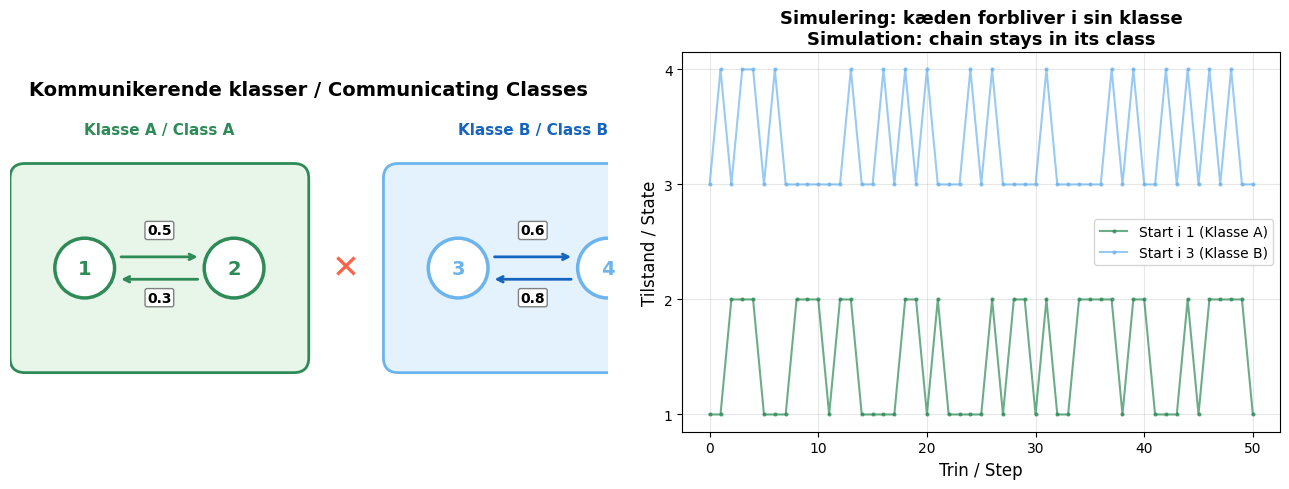

In [35]:
# --- Example 2: Communicating Classes - Graph Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: State transition diagram showing two classes
ax1.set_xlim(-1, 7)
ax1.set_ylim(-1.5, 2.2)
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title('Kommunikerende klasser / Communicating Classes', fontsize=14, fontweight='bold')

# Class A box
rect_a = mpatches.FancyBboxPatch((-0.8, -1.2), 3.6, 2.4, boxstyle='round,pad=0.2',
                                   facecolor='#E8F5E9', edgecolor='#2E8B57', linewidth=2)
ax1.add_patch(rect_a)
ax1.text(1, 1.8, 'Klasse A / Class A', ha='center', fontsize=11, fontweight='bold', color='#2E8B57')

# Class B box
rect_b = mpatches.FancyBboxPatch((4.2, -1.2), 3.6, 2.4, boxstyle='round,pad=0.2',
                                   facecolor='#E3F2FD', edgecolor='#6CB4EE', linewidth=2)
ax1.add_patch(rect_b)
ax1.text(6, 1.8, 'Klasse B / Class B', ha='center', fontsize=11, fontweight='bold', color='#1565C0')

# Draw states
positions = {1: (0, 0), 2: (2, 0), 3: (5, 0), 4: (7, 0)}
colors = {1: '#2E8B57', 2: '#2E8B57', 3: '#6CB4EE', 4: '#6CB4EE'}
for s, (x, y) in positions.items():
    circle = plt.Circle((x, y), 0.4, fill=True, facecolor='white', edgecolor=colors[s], linewidth=2.5)
    ax1.add_patch(circle)
    ax1.text(x, y, str(s), ha='center', va='center', fontsize=14, fontweight='bold', color=colors[s])

# Arrows within Class A
ax1.annotate('', xy=(1.55, 0.15), xytext=(0.45, 0.15),
             arrowprops=dict(arrowstyle='->', lw=2, color='#2E8B57'))
ax1.text(1, 0.45, '0.5', ha='center', fontsize=10, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='gray', zorder=10))
ax1.annotate('', xy=(0.45, -0.15), xytext=(1.55, -0.15),
             arrowprops=dict(arrowstyle='->', lw=2, color='#2E8B57'))
ax1.text(1, -0.45, '0.3', ha='center', fontsize=10, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='gray', zorder=10))

# Arrows within Class B
ax1.annotate('', xy=(6.55, 0.15), xytext=(5.45, 0.15),
             arrowprops=dict(arrowstyle='->', lw=2, color='#1565C0'))
ax1.text(6, 0.45, '0.6', ha='center', fontsize=10, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='gray', zorder=10))
ax1.annotate('', xy=(5.45, -0.15), xytext=(6.55, -0.15),
             arrowprops=dict(arrowstyle='->', lw=2, color='#1565C0'))
ax1.text(6, -0.45, '0.8', ha='center', fontsize=10, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='gray', zorder=10))

# No connection marker
ax1.text(3.5, 0, '✕', ha='center', va='center', fontsize=24, color='#FF6347', fontweight='bold')

# Right: Simulation from each class
P2 = np.array([[0.5, 0.5, 0, 0],
               [0.3, 0.7, 0, 0],
               [0, 0, 0.4, 0.6],
               [0, 0, 0.8, 0.2]])

np.random.seed(42)
for start, color, label in [(0, '#2E8B57', 'Start i 1 (Klasse A)'), (2, '#6CB4EE', 'Start i 3 (Klasse B)')]:
    trajectory = [start]
    state = start
    for _ in range(50):
        state = np.random.choice(4, p=P2[state])
        trajectory.append(state)
    ax2.plot(range(len(trajectory)), [s+1 for s in trajectory], '.-', color=color, alpha=0.7, label=label, markersize=4)

ax2.set_xlabel('Trin / Step', fontsize=12)
ax2.set_ylabel('Tilstand / State', fontsize=12)
ax2.set_yticks([1, 2, 3, 4])
ax2.set_title('Simulering: kæden forbliver i sin klasse\nSimulation: chain stays in its class', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# --- Example 2: Implementation - Identify communicating classes ---
P2 = np.array([[0.5, 0.5, 0, 0],
               [0.3, 0.7, 0, 0],
               [0, 0, 0.4, 0.6],
               [0, 0, 0.8, 0.2]])

print("=" * 55)
print("EKSEMPEL 2: Kommunikerende klasser / Communicating Classes")
print("=" * 55)

print(f"\nOvergangsmatrix P:\n{P2}")

# Check accessibility: compute P + P^2 + ... + P^n
n = 4
reachability = np.zeros((n, n))
Pk = np.eye(n)
for k in range(1, n + 1):
    Pk = Pk @ P2
    reachability += Pk

print(f"\nTilgængelighed (sum P^k, k=1..{n}) > 0:")
for i in range(n):
    for j in range(n):
        symbol = "→" if reachability[i, j] > 0 else "✕"
        print(f"  {i+1} {symbol} {j+1}  (sum = {reachability[i,j]:.4f})")

# Identify classes
print(f"\n📊 Kommunikerende klasser / Communicating classes:")
print(f"   Klasse A: {{1, 2}} — kommunikerer indbyrdes")
print(f"   Klasse B: {{3, 4}} — kommunikerer indbyrdes")
print(f"   Ingen forbindelse mellem A og B")
print(f"\n   Kæden er REDUCIBEL / The chain is REDUCIBLE")

# Stationary distribution for each class separately
print(f"\n📊 Stationære fordelinger per klasse / Stationary distributions per class:")
for name, sub_P, labels in [("Klasse A", P2[:2, :2], ['1', '2']),
                              ("Klasse B", P2[2:, 2:], ['3', '4'])]:
    evals, evecs = np.linalg.eig(sub_P.T)
    idx = np.argmin(np.abs(evals - 1.0))
    mu = np.real(evecs[:, idx])
    mu = mu / mu.sum()
    print(f"   {name}: μ({labels[0]}) = {mu[0]:.4f}, μ({labels[1]}) = {mu[1]:.4f}")

### Konklusion / Conclusion — Eksempel 2

**DK:** Kæden har to kommunikerende klasser: $\{1, 2\}$ og $\{3, 4\}$. Der er ingen overgang mellem dem — kæden er **reducibel**. Hver klasse har sin egen stationære fordeling. Hele kædens stationære fordeling afhænger af, hvilken klasse vi starter i — der er **ingen entydig** global stationær fordeling.

**EN:** The chain has two communicating classes: $\{1, 2\}$ and $\{3, 4\}$. There is no transition between them — the chain is **reducible**. Each class has its own stationary distribution. The chain's overall stationary distribution depends on which class we start in — there is **no unique** global stationary distribution.

---

## Eksempel 3: Periodisk kæde / Example 3: Periodic Chain

**DK:** En Markov-kæde med 3 tilstande der bevæger sig i en **cyklus**: $1 \to 2 \to 3 \to 1$. Kæden er irreducibel men **periodisk** med periode $d = 3$.

**EN:** A Markov chain with 3 states moving in a **cycle**: $1 \to 2 \to 3 \to 1$. The chain is irreducible but **periodic** with period $d = 3$.

$$P = \begin{pmatrix} 0 & 1 & 0 \\ 0 & 0 & 1 \\ 1 & 0 & 0 \end{pmatrix}$$

**DK:** Bemærk at $p_{i,i} = 0$ for alle $i$ — der er ingen selv-løkker. Den tidligste retur til tilstand 1 er efter 3 trin, dernæst 6, 9, ... Altså $d_1 = \text{GCD}\{3, 6, 9, \ldots\} = 3$.

**EN:** Note that $p_{i,i} = 0$ for all $i$ — there are no self-loops. The earliest return to state 1 is after 3 steps, then 6, 9, ... So $d_1 = \text{GCD}\{3, 6, 9, \ldots\} = 3$.

### Visuel oversigt / Visual Overview

```mermaid
stateDiagram-v2
    s1 : 1
    s2 : 2
    s3 : 3
    s1 --> s2 : 1.0
    s2 --> s3 : 1.0
    s3 --> s1 : 1.0
```

#### Graph-visning / Graph view

```mermaid
graph LR
    s1((1)) -->|1.0| s2((2))
    s2 -->|1.0| s3((3))
    s3 -->|1.0| s1
```

### LaTeX tilstandsdiagram / LaTeX state diagram

$$
\begin{array}{ccc}
 & \boxed{1} & \\[8pt]
 & \swarrow{\scriptstyle\;1.0} \quad & \\[8pt]
\boxed{3} & & \boxed{2} \\[-4pt]
 & \xleftarrow{\quad 1.0 \quad} &
\end{array}
\qquad \nwarrow{\scriptstyle\;1.0}
$$

**Cyklus / Cycle:**

$$\boxed{1} \xrightarrow{\;1.0\;} \boxed{2} \xrightarrow{\;1.0\;} \boxed{3} \xrightarrow{\;1.0\;} \boxed{1} \xrightarrow{\;1.0\;} \cdots$$

**Overgangsmatrix / Transition matrix:**

$$P = \begin{pmatrix} 0 & 1 & 0 \\ 0 & 0 & 1 \\ 1 & 0 & 0 \end{pmatrix}, \quad d = 3 \text{ (periode / period)}$$

**DK:** Kaeden roterer deterministisk. Den stationaere fordeling er $(1/3, 1/3, 1/3)$ — men fordelingen **konvergerer ikke** punkt-vis, den cykler!

**EN:** The chain rotates deterministically. The stationary distribution is $(1/3, 1/3, 1/3)$ — but the distribution **does not converge** pointwise, it cycles!

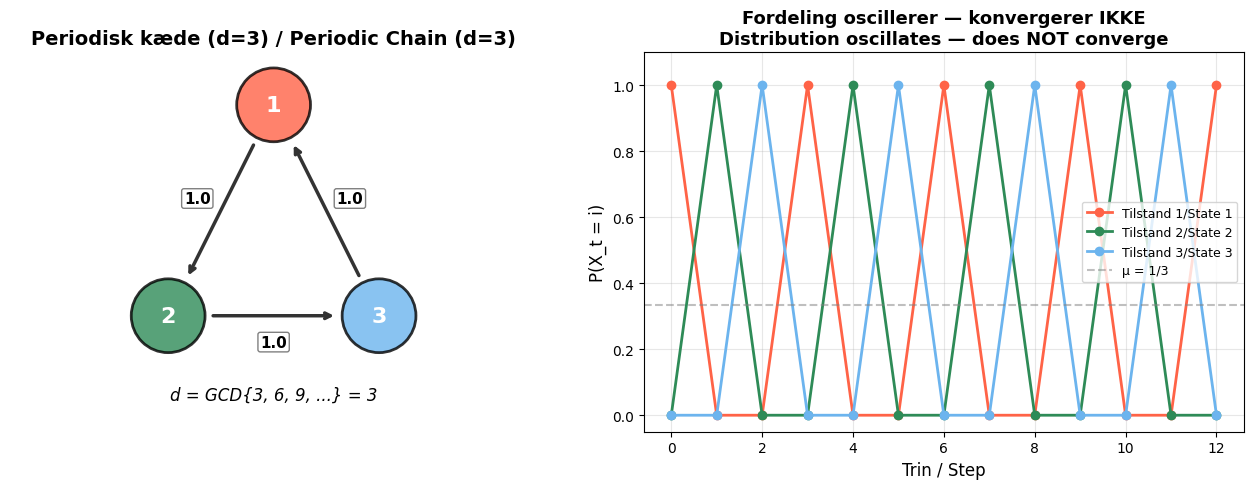

In [4]:
# --- Example 3: Periodic Chain - Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: Triangle state diagram
ax1.set_xlim(-1.5, 3.5)
ax1.set_ylim(-1.8, 1.8)
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title('Periodisk kæde (d=3) / Periodic Chain (d=3)', fontsize=14, fontweight='bold')

# Triangle positions
tri_pos = {1: (1, 1.3), 2: (0, -0.7), 3: (2, -0.7)}
tri_colors = ['#FF6347', '#2E8B57', '#6CB4EE']

for (s, (x, y)), c in zip(tri_pos.items(), tri_colors):
    circle = plt.Circle((x, y), 0.35, facecolor=c, edgecolor='black', linewidth=2, alpha=0.8)
    ax1.add_patch(circle)
    ax1.text(x, y, str(s), ha='center', va='center', fontsize=16, fontweight='bold', color='white')

# Arrows: 1→2, 2→3, 3→1
edges = [(1, 2), (2, 3), (3, 1)]
for (src, dst) in edges:
    x0, y0 = tri_pos[src]
    x1, y1 = tri_pos[dst]
    dx, dy = x1 - x0, y1 - y0
    dist = np.sqrt(dx**2 + dy**2)
    ux, uy = dx/dist, dy/dist
    ax1.annotate('', xy=(x1 - ux*0.4, y1 - uy*0.4), xytext=(x0 + ux*0.4, y0 + uy*0.4),
                 arrowprops=dict(arrowstyle='->', lw=2.5, color='#333'))
    mx, my = (x0+x1)/2, (y0+y1)/2
    ax1.text(mx + uy*0.25, my - ux*0.25, '1.0', ha='center', va='center', fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='gray'))

ax1.text(1, -1.5, 'd = GCD{3, 6, 9, ...} = 3', ha='center', fontsize=12, fontstyle='italic')

# Right: Distribution oscillation
P3 = np.array([[0, 1, 0],
               [0, 0, 1],
               [1, 0, 0]])
p = np.array([1.0, 0.0, 0.0])
steps = 12
dists = [p.copy()]
for _ in range(steps):
    p = p @ P3
    dists.append(p.copy())
dists = np.array(dists)

for i, (c, label) in enumerate(zip(tri_colors, ['Tilstand 1/State 1', 'Tilstand 2/State 2', 'Tilstand 3/State 3'])):
    ax2.plot(range(steps+1), dists[:, i], 'o-', color=c, linewidth=2, markersize=6, label=label)

ax2.axhline(y=1/3, color='gray', linestyle='--', alpha=0.5, label='μ = 1/3')
ax2.set_xlabel('Trin / Step', fontsize=12)
ax2.set_ylabel('P(X_t = i)', fontsize=12)
ax2.set_title('Fordeling oscillerer — konvergerer IKKE\nDistribution oscillates — does NOT converge', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_ylim(-0.05, 1.1)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# --- Example 3: Implementation - Period computation ---
P3 = np.array([[0, 1, 0],
               [0, 0, 1],
               [1, 0, 0]])

print("=" * 55)
print("EKSEMPEL 3: Periodisk kæde / Periodic Chain")
print("=" * 55)
print(f"\nP =\n{P3}")

# Compute period of state 1: find all m where P^m[0,0] > 0
from math import gcd
from functools import reduce

print(f"\nBeregn periode for tilstand 1 / Compute period of state 1:")
return_times = []
Pk = np.eye(3)
for m in range(1, 13):
    Pk = Pk @ P3
    if Pk[0, 0] > 1e-10:
        return_times.append(m)
        print(f"  P^{m}[1,1] = {Pk[0,0]:.4f}  ✓ retur mulig / return possible")
    else:
        print(f"  P^{m}[1,1] = {Pk[0,0]:.4f}")

period = reduce(gcd, return_times)
print(f"\nReturtider / Return times: {return_times}")
print(f"Periode / Period: d = GCD{set(return_times)} = {period}")

# Stationary distribution exists but convergence fails
print(f"\n📊 Stationær fordeling / Stationary distribution: μ = (1/3, 1/3, 1/3)")
print(f"   Men p_t konvergerer IKKE mod μ (perioden d=3 > 1)")
print(f"   But p_t does NOT converge to μ (period d=3 > 1)")

# Cesàro average DOES converge (ergodic theorem)
p = np.array([1.0, 0.0, 0.0])
cesaro = np.zeros(3)
for t in range(1, 301):
    p = p @ P3
    cesaro = cesaro + p
cesaro = cesaro / 300
print(f"\n✅ Cesàro-middel (300 trin) / Cesàro average (300 steps):")
print(f"   (1/T)·Σ p_t = ({cesaro[0]:.4f}, {cesaro[1]:.4f}, {cesaro[2]:.4f}) ≈ μ")

EKSEMPEL 3: Periodisk kæde / Periodic Chain

P =
[[0 1 0]
 [0 0 1]
 [1 0 0]]

Beregn periode for tilstand 1 / Compute period of state 1:
  P^1[1,1] = 0.0000
  P^2[1,1] = 0.0000
  P^3[1,1] = 1.0000  ✓ retur mulig / return possible
  P^4[1,1] = 0.0000
  P^5[1,1] = 0.0000
  P^6[1,1] = 1.0000  ✓ retur mulig / return possible
  P^7[1,1] = 0.0000
  P^8[1,1] = 0.0000
  P^9[1,1] = 1.0000  ✓ retur mulig / return possible
  P^10[1,1] = 0.0000
  P^11[1,1] = 0.0000
  P^12[1,1] = 1.0000  ✓ retur mulig / return possible

Returtider / Return times: [3, 6, 9, 12]
Periode / Period: d = GCD{9, 3, 12, 6} = 3

📊 Stationær fordeling / Stationary distribution: μ = (1/3, 1/3, 1/3)
   Men p_t konvergerer IKKE mod μ (perioden d=3 > 1)
   But p_t does NOT converge to μ (period d=3 > 1)

✅ Cesàro-middel (300 trin) / Cesàro average (300 steps):
   (1/T)·Σ p_t = (0.3333, 0.3333, 0.3333) ≈ μ


### Konklusion / Conclusion — Eksempel 3

**DK:** Periodiske kæder har en stationær fordeling ($\mu = (1/3, 1/3, 1/3)$), men fordelingen konvergerer **ikke** punkt-vis — den cykler i stedet. Dog konvergerer **Cesàro-midlet** (tidsgennemsnittet) mod $\mu$, i overensstemmelse med den ergodiske sætning (Theorem 4.9, punkt 4). For at opnå punkt-vis konvergens kræves **aperiodicitet** ($d = 1$).

**EN:** Periodic chains have a stationary distribution ($\mu = (1/3, 1/3, 1/3)$) but the distribution does **not** converge pointwise — it cycles instead. However, the **Cesàro average** (time average) does converge to $\mu$, consistent with the ergodic theorem (Theorem 4.9, point 4). Pointwise convergence requires **aperiodicity** ($d = 1$).

---

## Eksempel 4: Transiente og rekurrente tilstande / Example 4: Transient and Recurrent States

**DK:** En kæde med 4 tilstande hvor tilstand 4 er **absorberende** ($p_{4,4} = 1$). Tilstande $\{1, 2\}$ er transiente — kæden forlader dem til sidst for altid.

**EN:** A chain with 4 states where state 4 is **absorbing** ($p_{4,4} = 1$). States $\{1, 2\}$ are transient — the chain eventually leaves them forever.

$$P = \begin{pmatrix} 0.3 & 0.5 & 0.2 & 0 \\ 0.1 & 0.4 & 0 & 0.5 \\ 0 & 0 & 0.6 & 0.4 \\ 0 & 0 & 0 & 1.0 \end{pmatrix}$$

| Tilstand / State | Klasse / Class | Type |
|-----------------|---------------|------|
| 1 | $\{1, 2\}$ | Transient — kan nå 3 og 4, men de kan ikke nå tilbage |
| 2 | $\{1, 2\}$ | Transient — kan nå 4, kan ikke vende tilbage |
| 3 | $\{3\}$ | Transient — drain mod 4 ($p_{3,4} = 0.4$) |
| 4 | $\{4\}$ | **Rekurrent** (absorberende, $p_{4,4} = 1$) |

### Visuel oversigt / Visual Overview

```mermaid
stateDiagram-v2
    s1 : 1 (transient)
    s2 : 2 (transient)
    s3 : 3 (transient)
    s4 : 4 (absorberende)
    s1 --> s1 : 0.3
    s1 --> s2 : 0.5
    s1 --> s3 : 0.2
    s2 --> s1 : 0.1
    s2 --> s2 : 0.4
    s2 --> s4 : 0.5
    s3 --> s3 : 0.6
    s3 --> s4 : 0.4
    s4 --> s4 : 1.0
```

#### Graph-visning / Graph view

```mermaid
graph LR
    s1((1)) -->|0.3| s1
    s1 -->|0.5| s2((2))
    s1 -->|0.2| s3((3))
    s2 -->|0.1| s1
    s2 -->|0.4| s2
    s2 -->|0.5| s4[["4 (absorb.)"]]
    s3 -->|0.6| s3
    s3 -->|0.4| s4
    s4 -->|1.0| s4
    style s4 fill:#FF6347,color:#fff
```

### LaTeX tilstandsdiagram / LaTeX state diagram

$$
\begin{array}{ccccccc}
 & & \xrightarrow{\quad 0.5 \quad} & & & & \\[-4pt]
\boxed{1} & & & & \boxed{2} & \xrightarrow{\;0.5\;} & \boxed{\mathbf{4}} \\[-4pt]
 & & \xleftarrow{\quad 0.1 \quad} & & & & \\[6pt]
{\scriptstyle 0.3}\;\circlearrowleft & & & & {\scriptstyle 0.4}\;\circlearrowleft & & {\scriptstyle \mathbf{1.0}}\;\circlearrowleft \\[6pt]
 & \searrow^{0.2} & & \nearrow^{0.4} & & & \\[6pt]
 & & \boxed{3} & & & & \\[4pt]
 & & {\scriptstyle 0.6}\;\circlearrowleft & & & &
\end{array}
$$

$$
\underbrace{1, 2, 3}_{\text{transient}} \longrightarrow \underbrace{\mathbf{4}}_{\text{absorberende / absorbing}}
$$

**Overgangsmatrix / Transition matrix:**

$$P = \begin{pmatrix} 0.3 & 0.5 & 0.2 & 0 \\ 0.1 & 0.4 & 0 & 0.5 \\ 0 & 0 & 0.6 & 0.4 \\ 0 & 0 & 0 & 1.0 \end{pmatrix}$$

**DK:** Alle veje foerer til Rom — eller i dette tilfaelde til tilstand 4. Alle transiente tilstande "toemmes" over tid.

**EN:** All roads lead to Rome — or in this case, to state 4. All transient states "drain" over time.

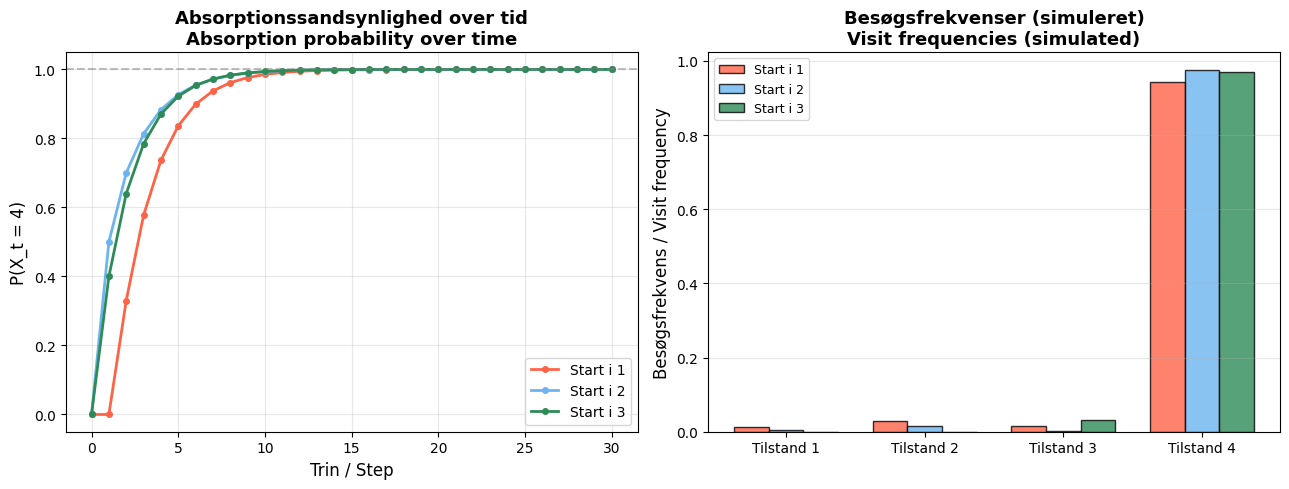

In [6]:
# --- Example 4: Transient vs Recurrent - Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: Absorption probability over time
P4 = np.array([[0.3, 0.5, 0.2, 0.0],
               [0.1, 0.4, 0.0, 0.5],
               [0.0, 0.0, 0.6, 0.4],
               [0.0, 0.0, 0.0, 1.0]])

steps = 30
for start, color, label in [(0, '#FF6347', 'Start i 1'), (1, '#6CB4EE', 'Start i 2'), (2, '#2E8B57', 'Start i 3')]:
    p = np.zeros(4)
    p[start] = 1.0
    absorption = []
    for t in range(steps + 1):
        absorption.append(p[3])
        p = p @ P4
    ax1.plot(range(steps+1), absorption, 'o-', color=color, markersize=4, linewidth=2, label=label)

ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('Trin / Step', fontsize=12)
ax1.set_ylabel('P(X_t = 4)', fontsize=12)
ax1.set_title('Absorptionssandsynlighed over tid\nAbsorption probability over time', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Right: State visit frequencies
np.random.seed(42)
n_sim = 1000
T_sim = 50
visit_counts = np.zeros((3, 4))

for start in range(3):
    for _ in range(n_sim):
        state = start
        for t in range(T_sim):
            state = np.random.choice(4, p=P4[state])
            visit_counts[start, state] += 1

visit_freq = visit_counts / (n_sim * T_sim)
x = np.arange(4)
width = 0.25
for i, (color, label) in enumerate(zip(['#FF6347', '#6CB4EE', '#2E8B57'],
                                         ['Start i 1', 'Start i 2', 'Start i 3'])):
    bars = ax2.bar(x + i*width - width, visit_freq[i], width, color=color, alpha=0.8, label=label, edgecolor='black')

ax2.set_xticks(x)
ax2.set_xticklabels(['Tilstand 1', 'Tilstand 2', 'Tilstand 3', 'Tilstand 4'], fontsize=10)
ax2.set_ylabel('Besøgsfrekvens / Visit frequency', fontsize=12)
ax2.set_title('Besøgsfrekvenser (simuleret)\nVisit frequencies (simulated)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [7]:
# --- Example 4: Implementation - Transient/Recurrent analysis ---
P4 = np.array([[0.3, 0.5, 0.2, 0.0],
               [0.1, 0.4, 0.0, 0.5],
               [0.0, 0.0, 0.6, 0.4],
               [0.0, 0.0, 0.0, 1.0]])

print("=" * 55)
print("EKSEMPEL 4: Transiente & rekurrente tilstande")
print("           Transient & Recurrent States")
print("=" * 55)
print(f"\nP =\n{P4}")

# Check sum of p_{i,i}^{(m)} for each state (Claim 4.2)
print(f"\n📊 Σ p_ii^(m) for m=1..100 (Claim 4.2: endelig ⟹ transient):")
Pk = np.eye(4)
diag_sums = np.zeros(4)
for m in range(1, 101):
    Pk = Pk @ P4
    diag_sums += np.diag(Pk)

for i in range(4):
    status = "TRANSIENT" if diag_sums[i] < 50 else "REKURRENT"
    print(f"  Tilstand {i+1}: Σ = {diag_sums[i]:>8.4f}  → {status}")

# Absorption time from each state
print(f"\n📊 Forventet absorptionstid til tilstand 4 / Expected absorption time to state 4:")
print("   (Simuleret med 10.000 kørsler / Simulated with 10,000 runs)")
np.random.seed(42)
for start in range(3):
    times = []
    for _ in range(10000):
        state = start
        t = 0
        while state != 3:
            state = np.random.choice(4, p=P4[state])
            t += 1
        times.append(t)
    print(f"  Fra tilstand {start+1}: E[T_4] ≈ {np.mean(times):.2f} trin (std = {np.std(times):.2f})")

print(f"\n✅ Tilstand 4 er absorberende: p(4,4) = 1.0")
print(f"   Alle andre tilstande drænes mod 4 over tid.")

EKSEMPEL 4: Transiente & rekurrente tilstande
           Transient & Recurrent States

P =
[[0.3 0.5 0.2 0. ]
 [0.1 0.4 0.  0.5]
 [0.  0.  0.6 0.4]
 [0.  0.  0.  1. ]]

📊 Σ p_ii^(m) for m=1..100 (Claim 4.2: endelig ⟹ transient):
  Tilstand 1: Σ =   0.6216  → TRANSIENT
  Tilstand 2: Σ =   0.8919  → TRANSIENT
  Tilstand 3: Σ =   1.5000  → TRANSIENT
  Tilstand 4: Σ = 100.0000  → REKURRENT

📊 Forventet absorptionstid til tilstand 4 / Expected absorption time to state 4:
   (Simuleret med 10.000 kørsler / Simulated with 10,000 runs)
  Fra tilstand 1: E[T_4] ≈ 3.77 trin (std = 2.07)
  Fra tilstand 2: E[T_4] ≈ 2.30 trin (std = 1.96)
  Fra tilstand 3: E[T_4] ≈ 2.48 trin (std = 1.92)

✅ Tilstand 4 er absorberende: p(4,4) = 1.0
   Alle andre tilstande drænes mod 4 over tid.


### Konklusion / Conclusion — Eksempel 4

**DK:** Tilstande $\{1, 2, 3\}$ er transiente — summen $\sum_m p_{i,i}^{(m)}$ er endelig (Claim 4.2). Al sandsynlighedsmasse dræneres mod den absorberende tilstand 4. Bemærk at tilstand 3 når tilstand 4 hurtigst (direkte $p_{3,4} = 0.4$), mens tilstand 1 tager længst (skal først igennem 2 eller 3).

**EN:** States $\{1, 2, 3\}$ are transient — the sum $\sum_m p_{i,i}^{(m)}$ is finite (Claim 4.2). All probability mass drains toward the absorbing state 4. Note that state 3 reaches state 4 fastest (direct $p_{3,4} = 0.4$), while state 1 takes longest (must go through 2 or 3 first).

---

## Eksempel 5: Spiller-ruin (Random Walk) / Example 5: Gambler's Ruin (Random Walk)

**DK:** En spiller starter med $k$ kroner og satser 1 krone per runde. Med sandsynlighed $p$ vinder hun (+1), med $q = 1-p$ taber hun (-1). Spillet stopper når hun er gået fallit (0) eller har nået målet $N$.

**EN:** A gambler starts with $k$ kroner and bets 1 krone per round. With probability $p$ she wins (+1), with $q = 1-p$ she loses (-1). The game ends when she is broke (0) or has reached the target $N$.

### Tilstande / States: $\mathcal{X} = \{0, 1, 2, \ldots, N\}$

$$p_{i,i+1} = p, \quad p_{i,i-1} = q = 1-p, \quad p_{0,0} = p_{N,N} = 1 \text{ (absorberende)}$$

**Parametre / Parameters:** $N = 6$, $p = 0.4$ (ufordelagtig / unfavorable), start $k = 3$

**Spørgsmål / Questions:**
1. Hvad er sandsynligheden for at nå $N$ (vinde)? / What is the probability of reaching $N$ (winning)?
2. Hvor lang tid tager det i gennemsnit? / How long does it take on average?

### Visuel oversigt / Visual Overview

```mermaid
graph LR
    s0["0 Ruin"] -->|1.0| s0
    s1["1"] -->|"q=0.6"| s0
    s1 -->|"p=0.4"| s2["2"]
    s2 -->|q| s1
    s2 -->|p| s3["3 ★ Start"]
    s3 -->|q| s2
    s3 -->|p| s4["4"]
    s4 -->|q| s3
    s4 -->|p| s5["5"]
    s5 -->|q| s4
    s5 -->|p| s6["6 Maal/Goal"]
    s6 -->|1.0| s6
```

### LaTeX tilstandsdiagram / LaTeX state diagram

$$
\fbox{0\;(\text{ruin})} \;\xleftarrow{\;q\;}\;
\boxed{1} \;\underset{q}{\overset{p}{\rightleftarrows}}\;
\boxed{2} \;\underset{q}{\overset{p}{\rightleftarrows}}\;
\boxed{\mathbf{3\;\bigstar}} \;\underset{q}{\overset{p}{\rightleftarrows}}\;
\boxed{4} \;\underset{q}{\overset{p}{\rightleftarrows}}\;
\boxed{5} \;\xrightarrow{\;p\;}\;
\fbox{6\;(\text{maal})}
$$

$$p = 0.4, \quad q = 1-p = 0.6, \quad \text{start } k=3, \quad \text{maal } N = 6$$

$$\circlearrowleft\; \fbox{0} \qquad\qquad\qquad \underbrace{1 \;\rightleftarrows\; 2 \;\rightleftarrows\; 3 \;\rightleftarrows\; 4 \;\rightleftarrows\; 5}_{\text{transiente tilstande / transient states}} \qquad\qquad\qquad \fbox{6}\;\circlearrowright$$

**DK:** Tilstande $\{1, 2, 3, 4, 5\}$ er transiente — kaeden ender altid i enten 0 (ruin) eller $N$ (maal). Med $p < 0.5$ forventer vi, at ruin er mest sandsynlig.

**EN:** States $\{1, 2, 3, 4, 5\}$ are transient — the chain always ends in either 0 (ruin) or $N$ (goal). With $p < 0.5$, we expect ruin to be most likely.

/tmp/ipykernel_25227/3202465973.py:70: UserWarning: Glyph 128128 (\N{SKULL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_25227/3202465973.py:70: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/guldmand/DataScience/conda_envs/ml/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128128 (\N{SKULL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/guldmand/DataScience/conda_envs/ml/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


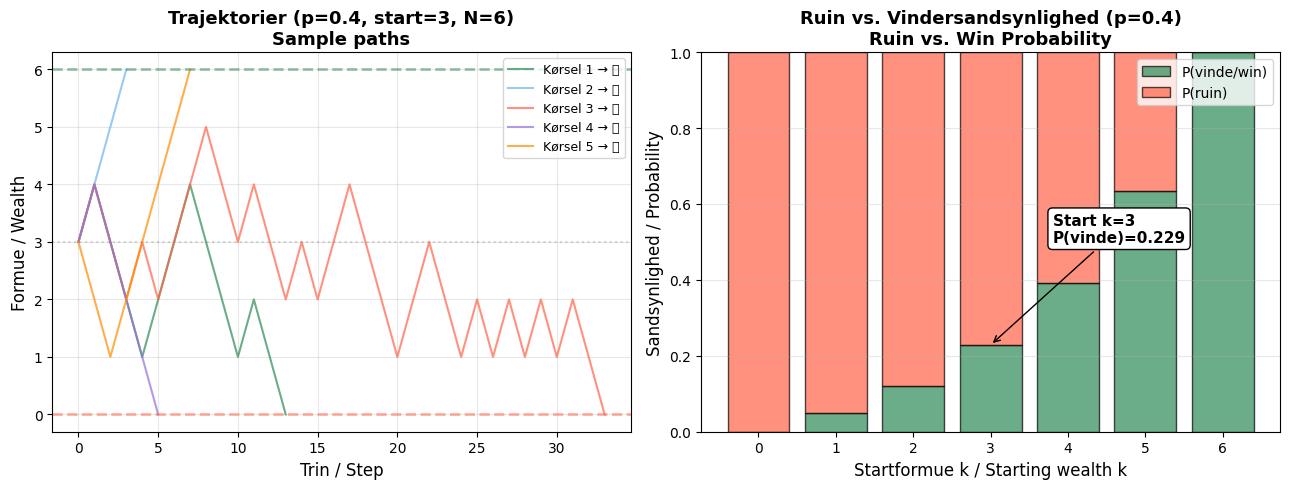

In [8]:
# --- Example 5: Gambler's Ruin - Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

N = 6
p_win = 0.4
q_lose = 1 - p_win
k_start = 3

# Left: Sample trajectories
np.random.seed(42)
colors_traj = ['#2E8B57', '#6CB4EE', '#FF6347', '#9370DB', '#FF8C00']
for trial, color in enumerate(colors_traj):
    state = k_start
    trajectory = [state]
    while state > 0 and state < N:
        if np.random.random() < p_win:
            state += 1
        else:
            state -= 1
        trajectory.append(state)
    result = "🏆" if trajectory[-1] == N else "💀"
    ax1.plot(range(len(trajectory)), trajectory, '-', color=color, linewidth=1.5, alpha=0.7,
             label=f'Kørsel {trial+1} → {result}')

ax1.axhline(y=0, color='#FF6347', linestyle='--', alpha=0.5, linewidth=2)
ax1.axhline(y=N, color='#2E8B57', linestyle='--', alpha=0.5, linewidth=2)
ax1.axhline(y=k_start, color='gray', linestyle=':', alpha=0.3)
ax1.set_xlabel('Trin / Step', fontsize=12)
ax1.set_ylabel('Formue / Wealth', fontsize=12)
ax1.set_title(f'Trajektorier (p={p_win}, start={k_start}, N={N})\nSample paths', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9, loc='upper right')
ax1.set_yticks(range(N+1))
ax1.grid(True, alpha=0.3)

# Right: Ruin probability for each starting state (analytical)
# P(ruin from k) = 1 - [(r^k - 1)/(r^N - 1)] where r = q/p
r = q_lose / p_win
ruin_prob = []
win_prob = []
for k in range(N+1):
    if k == 0:
        ruin_prob.append(1.0)
        win_prob.append(0.0)
    elif k == N:
        ruin_prob.append(0.0)
        win_prob.append(1.0)
    else:
        pw = (r**k - 1) / (r**N - 1)
        win_prob.append(pw)
        ruin_prob.append(1 - pw)

colors_bar = ['#FF6347' if rp > 0.5 else '#2E8B57' for rp in ruin_prob]
bars = ax2.bar(range(N+1), win_prob, color=['#2E8B57']*len(win_prob), alpha=0.7, edgecolor='black', label='P(vinde/win)')
ax2.bar(range(N+1), ruin_prob, bottom=win_prob, color=['#FF6347']*len(ruin_prob), alpha=0.7, edgecolor='black', label='P(ruin)')

# Highlight start position
ax2.annotate(f'Start k={k_start}\nP(vinde)={win_prob[k_start]:.3f}',
             xy=(k_start, win_prob[k_start]), xytext=(k_start+0.8, 0.5),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='white', edgecolor='black'))

ax2.set_xlabel('Startformue k / Starting wealth k', fontsize=12)
ax2.set_ylabel('Sandsynlighed / Probability', fontsize=12)
ax2.set_title(f'Ruin vs. Vindersandsynlighed (p={p_win})\nRuin vs. Win Probability', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.set_xticks(range(N+1))
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [9]:
# --- Example 5: Implementation - Gambler's Ruin analytics ---
N = 6
p_win = 0.4
q_lose = 1 - p_win
r = q_lose / p_win

print("=" * 55)
print("EKSEMPEL 5: Spiller-ruin / Gambler's Ruin")
print("=" * 55)
print(f"\nParametre: N={N}, p={p_win}, q={q_lose}, r=q/p={r:.4f}")

# Analytical ruin probabilities
print(f"\n📊 Analytiske vindersandsynligheder / Analytical win probabilities:")
print(f"   P(vinde fra k) = (r^k - 1) / (r^N - 1)  for r ≠ 1")
print(f"{'k':>5} | {'P(vinde/win)':>14} | {'P(ruin)':>14}")
print("-" * 40)
for k in range(N+1):
    if k == 0:
        pw = 0.0
    elif k == N:
        pw = 1.0
    else:
        pw = (r**k - 1) / (r**N - 1)
    print(f"{k:>5} | {pw:>14.6f} | {1-pw:>14.6f}")

# Simulation verification
np.random.seed(42)
n_sim = 50000
wins = 0
total_steps = 0
for _ in range(n_sim):
    state = 3  # start at k=3
    steps = 0
    while state > 0 and state < N:
        state += 1 if np.random.random() < p_win else -1
        steps += 1
    if state == N:
        wins += 1
    total_steps += steps

k = 3
pw_analytical = (r**k - 1) / (r**N - 1)
print(f"\n✅ Verifikation (simulering, {n_sim:,} kørsler fra k={k}):")
print(f"   P(vinde) analytisk  = {pw_analytical:.6f}")
print(f"   P(vinde) simuleret  = {wins/n_sim:.6f}")
print(f"   E[spilletid]        ≈ {total_steps/n_sim:.1f} trin")

EKSEMPEL 5: Spiller-ruin / Gambler's Ruin

Parametre: N=6, p=0.4, q=0.6, r=q/p=1.5000

📊 Analytiske vindersandsynligheder / Analytical win probabilities:
   P(vinde fra k) = (r^k - 1) / (r^N - 1)  for r ≠ 1
    k |   P(vinde/win) |        P(ruin)
----------------------------------------
    0 |       0.000000 |       1.000000
    1 |       0.048120 |       0.951880
    2 |       0.120301 |       0.879699
    3 |       0.228571 |       0.771429
    4 |       0.390977 |       0.609023
    5 |       0.634586 |       0.365414
    6 |       1.000000 |       0.000000

✅ Verifikation (simulering, 50,000 kørsler fra k=3):
   P(vinde) analytisk  = 0.228571
   P(vinde) simuleret  = 0.228180
   E[spilletid]        ≈ 8.2 trin


### Konklusion / Conclusion — Eksempel 5

**DK:** Med $p = 0.4 < 0.5$ (ufordelagtig satsning) er ruinsandsynligheden høj: fra $k = 3$ er $P(\text{ruin}) \approx 0.87$. Formlen $P(\text{vinde fra } k) = \frac{(q/p)^k - 1}{(q/p)^N - 1}$ viser, at selv små handicaps ($p < 0.5$) giver dramatisk høj ruinrisiko. **Alle indre tilstande er transiente** — kæden ender altid i en absorberende tilstand (0 eller $N$).

**EN:** With $p = 0.4 < 0.5$ (unfavorable bet), the ruin probability is high: from $k = 3$, $P(\text{ruin}) \approx 0.87$. The formula $P(\text{win from } k) = \frac{(q/p)^k - 1}{(q/p)^N - 1}$ shows that even small handicaps ($p < 0.5$) give dramatically high ruin risk. **All interior states are transient** — the chain always ends in an absorbing state (0 or $N$).

---

## Eksempel 6: PageRank som Markov-kæde / Example 6: PageRank as a Markov Chain

**DK:** Google's PageRank-algoritme modellerer en "tilfældig surfer" på internettet som en Markov-kæde. Surferens position er tilstanden, og links er overgangene. Den stationære fordeling $\mu$ giver vigtigheden af hver side.

**EN:** Google's PageRank algorithm models a "random surfer" on the internet as a Markov chain. The surfer's position is the state, and links are the transitions. The stationary distribution $\mu$ gives the importance of each page.

### Lille webgraf med 5 sider / Small webgraph with 5 pages

| Side / Page | Links til / Links to |
|-------------|---------------------|
| A | B, C |
| B | C |
| C | A |
| D | C |
| E | D, A |

### Damping-faktor / Damping factor

$$P_{\text{PageRank}} = \alpha \cdot P_{\text{links}} + (1 - \alpha) \cdot \frac{1}{n} \mathbf{1}\mathbf{1}^\top$$

**DK:** Med $\alpha \in (0,1)$ (typisk $\alpha = 0.85$) tilføjes en lille sandsynlighed for at "teleportere" til en tilfældig side — dette gør kæden **irreducibel** og **aperiodisk**.

**EN:** With $\alpha \in (0,1)$ (typically $\alpha = 0.85$), a small probability of "teleporting" to a random page is added — this makes the chain **irreducible** and **aperiodic**.

### Visuel oversigt / Visual Overview

```mermaid
graph LR
    A((A)) -->|link| B((B))
    A -->|link| C((C))
    B -->|link| C
    C -->|link| A
    D((D)) -->|link| C
    E((E)) -->|link| D
    E -->|link| A
```

### LaTeX webgraf / LaTeX web graph

$$
\begin{array}{ccc}
 & \xrightarrow{\quad\text{link}\quad} & \\[-4pt]
\boxed{A} & & \boxed{B} \\[4pt]
 & \searrow^{\text{link}} & \downarrow{\scriptstyle\;\text{link}} \\[4pt]
 & & \boxed{C} \\[4pt]
 & \nearrow^{\text{link}} & \uparrow{\scriptstyle\;\text{link}} \\[4pt]
\boxed{E} & \xrightarrow{\;\text{link}\;} & \boxed{D}
\end{array}
$$

**PageRank-formel / PageRank formula:**

$$P_{\text{PageRank}} = \alpha \cdot P_{\text{links}} + (1 - \alpha) \cdot \frac{1}{n}\mathbf{1}\mathbf{1}^\top, \quad \alpha = 0.85$$

**DK:** Surfer foelger links med $P = 0.85$, teleporterer til tilfaeldig side med $P = 0.15$. Damping goer kaeden **irreducibel** og **aperiodisk**.

**EN:** Surfer follows links with $P = 0.85$, teleports to a random page with $P = 0.15$. Damping makes the chain **irreducible** and **aperiodic**.

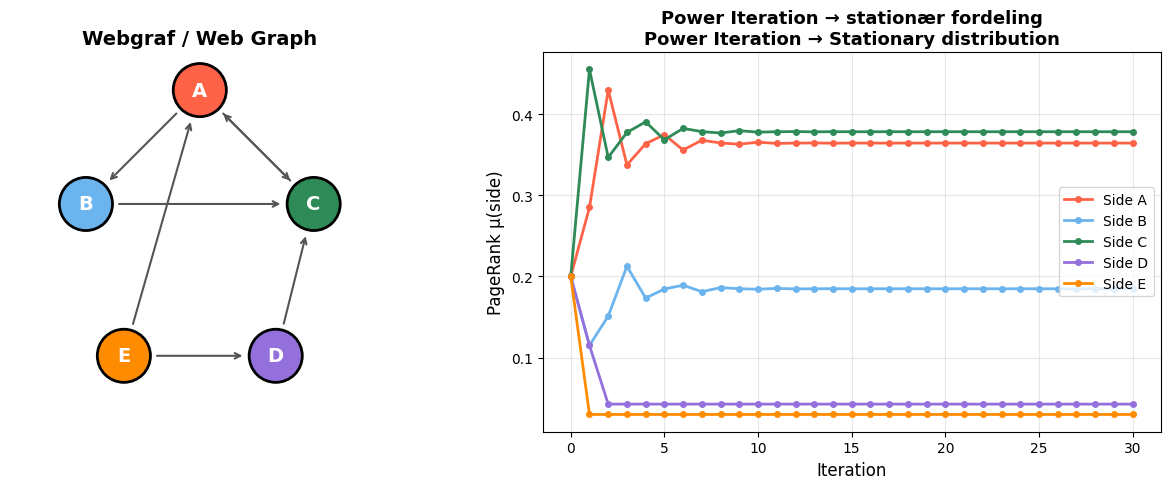

In [10]:
# --- Example 6: PageRank - Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: Web graph visualization
ax1.set_xlim(-0.5, 4.5)
ax1.set_ylim(-0.5, 4.5)
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title('Webgraf / Web Graph', fontsize=14, fontweight='bold')

pages = {'A': (2, 4), 'B': (0.5, 2.5), 'C': (3.5, 2.5), 'D': (3, 0.5), 'E': (1, 0.5)}
page_colors = {'A': '#FF6347', 'B': '#6CB4EE', 'C': '#2E8B57', 'D': '#9370DB', 'E': '#FF8C00'}

for page, (x, y) in pages.items():
    circle = plt.Circle((x, y), 0.35, facecolor=page_colors[page], edgecolor='black', linewidth=2)
    ax1.add_patch(circle)
    ax1.text(x, y, page, ha='center', va='center', fontsize=14, fontweight='bold', color='white')

# Draw links
links = [('A', 'B'), ('A', 'C'), ('B', 'C'), ('C', 'A'), ('D', 'C'), ('E', 'D'), ('E', 'A')]
for src, dst in links:
    x0, y0 = pages[src]
    x1, y1 = pages[dst]
    dx, dy = x1 - x0, y1 - y0
    dist = np.sqrt(dx**2 + dy**2)
    ux, uy = dx/dist, dy/dist
    ax1.annotate('', xy=(x1 - ux*0.4, y1 - uy*0.4), xytext=(x0 + ux*0.4, y0 + uy*0.4),
                 arrowprops=dict(arrowstyle='->', lw=1.5, color='#555'))

# Right: Power iteration convergence
n = 5  # A=0, B=1, C=2, D=3, E=4
P_links = np.zeros((n, n))
link_map = {'A': ['B', 'C'], 'B': ['C'], 'C': ['A'], 'D': ['C'], 'E': ['D', 'A']}
idx = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}

for src, dests in link_map.items():
    for dst in dests:
        P_links[idx[src], idx[dst]] = 1.0 / len(dests)

alpha = 0.85
P_pr = alpha * P_links + (1 - alpha) / n * np.ones((n, n))

# Power iteration
mu = np.ones(n) / n
history = [mu.copy()]
for _ in range(30):
    mu = mu @ P_pr
    mu = mu / mu.sum()
    history.append(mu.copy())
history = np.array(history)

for i, (page, color) in enumerate(page_colors.items()):
    ax2.plot(range(len(history)), history[:, i], 'o-', color=color, markersize=4, linewidth=2, label=f'Side {page}')

ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('PageRank μ(side)', fontsize=12)
ax2.set_title('Power Iteration → stationær fordeling\nPower Iteration → Stationary distribution', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# --- Example 6: Implementation - PageRank computation ---
n = 5
page_names = ['A', 'B', 'C', 'D', 'E']

# Build link matrix
P_links = np.zeros((n, n))
link_map = {0: [1, 2], 1: [2], 2: [0], 3: [2], 4: [3, 0]}  # A→B,C; B→C; C→A; D→C; E→D,A
for src, dests in link_map.items():
    for dst in dests:
        P_links[src, dst] = 1.0 / len(dests)

alpha = 0.85
P_pr = alpha * P_links + (1 - alpha) / n * np.ones((n, n))

print("=" * 55)
print("EKSEMPEL 6: PageRank som Markov-kæde")
print("           PageRank as a Markov Chain")
print("=" * 55)
print(f"\nDamping α = {alpha}")
print(f"\nLink-matrix P_links:")
for i, name in enumerate(page_names):
    print(f"  {name}: {P_links[i]}")

print(f"\nPageRank-matrix P_PR (med damping):")
for i, name in enumerate(page_names):
    print(f"  {name}: [{', '.join(f'{x:.3f}' for x in P_pr[i])}]")

# Power iteration
mu = np.ones(n) / n
for iteration in range(50):
    mu_new = mu @ P_pr
    mu_new = mu_new / mu_new.sum()
    if np.max(np.abs(mu_new - mu)) < 1e-10:
        print(f"\nKonvergeret efter {iteration+1} iterationer / Converged after {iteration+1} iterations")
        break
    mu = mu_new

print(f"\n📊 PageRank (stationær fordeling):")
ranking = sorted(zip(page_names, mu), key=lambda x: -x[1])
for rank, (name, score) in enumerate(ranking, 1):
    bar = '█' * int(score * 100)
    print(f"  #{rank} Side {name}: μ = {score:.4f}  {bar}")

# Verify: μP = μ
print(f"\n✅ Verifikation: μ·P ≈ μ ?")
mu_check = mu @ P_pr
print(f"   max|μP - μ| = {np.max(np.abs(mu_check - mu)):.2e}")

EKSEMPEL 6: PageRank som Markov-kæde
           PageRank as a Markov Chain

Damping α = 0.85

Link-matrix P_links:
  A: [0.  0.5 0.5 0.  0. ]
  B: [0. 0. 1. 0. 0.]
  C: [1. 0. 0. 0. 0.]
  D: [0. 0. 1. 0. 0.]
  E: [0.5 0.  0.  0.5 0. ]

PageRank-matrix P_PR (med damping):
  A: [0.030, 0.455, 0.455, 0.030, 0.030]
  B: [0.030, 0.030, 0.880, 0.030, 0.030]
  C: [0.880, 0.030, 0.030, 0.030, 0.030]
  D: [0.030, 0.030, 0.880, 0.030, 0.030]
  E: [0.455, 0.030, 0.030, 0.455, 0.030]

Konvergeret efter 44 iterationer / Converged after 44 iterations

📊 PageRank (stationær fordeling):
  #1 Side C: μ = 0.3782  █████████████████████████████████████
  #2 Side A: μ = 0.3642  ████████████████████████████████████
  #3 Side B: μ = 0.1848  ██████████████████
  #4 Side D: μ = 0.0428  ████
  #5 Side E: μ = 0.0300  ███

✅ Verifikation: μ·P ≈ μ ?
   max|μP - μ| = 5.61e-11


### Konklusion / Conclusion — Eksempel 6

**DK:** Side C har højest PageRank fordi den modtager links fra flest sider (A, B, D). Damping-faktoren $\alpha = 0.85$ sikrer, at kæden er irreducibel og aperiodisk, så den ergodiske sætning gælder. **Power iteration** ($\mu_{t+1} = \mu_t P$) konvergerer hurtigt til den stationære fordeling — dette er præcis den algoritme, Google bruger.

**EN:** Page C has the highest PageRank because it receives links from the most pages (A, B, D). The damping factor $\alpha = 0.85$ ensures the chain is irreducible and aperiodic, so the ergodic theorem applies. **Power iteration** ($\mu_{t+1} = \mu_t P$) converges quickly to the stationary distribution — this is exactly the algorithm Google uses.

---

## Eksempel 7: Diskret-tids kø (Example 4.4) / Example 7: Discrete-Time Queue

**DK:** Et køsystem modelleret som en Markov-kæde (fra bogens Eksempel 4.4). Kølængden $X_t \in \{0, 1, 2, \ldots\}$ afhænger af ankomster og betjening:

$$X_{t+1} = (X_t + A_t - S_t)^+$$

Ankomster: $A_t \sim \text{Bernoulli}(p)$, Betjening: $S_t \sim \text{Bernoulli}(q)$

**EN:** A queuing system modeled as a Markov chain (from textbook Example 4.4). The queue length $X_t \in \{0, 1, 2, \ldots\}$ depends on arrivals and service:

### Overgangssandsynligheder (for $i > 0$) / Transition probabilities

| Overgang / Transition | Sandsynlighed / Probability | Hændelse / Event |
|-----------------------|---------------------------|-----------------|
| $i \to i+1$ | $\lambda = p(1-q)$ | Ankomst, ingen betjening |
| $i \to i$ | $(1-p)(1-q) + pq$ | Begge ens (ingen ændring) |
| $i \to i-1$ | $\eta = (1-p)q$ | Ingen ankomst, betjening |

### Detaljeret balance / Detailed balance
$$\mu_i \lambda = \mu_{i+1} \eta \implies \mu_i = \mu_0 \rho^i, \quad \rho = \frac{\lambda}{\eta} = \frac{p(1-q)}{(1-p)q}$$

**Stabil kø (stationær fordeling eksisterer) iff $\rho < 1$:** $\mu_0 = 1 - \rho$

**Parametre:** $p = 0.3$ (ankomstrate), $q = 0.5$ (betjeningsrate), $\rho = 0.3 \cdot 0.5 / (0.7 \cdot 0.5) = 3/7 \approx 0.429$

### Visuel oversigt / Visual Overview

```mermaid
stateDiagram-v2
    s0 : Koe = 0
    s1 : Koe = 1
    s2 : Koe = 2
    s3 : Koe = 3 ...
    s0 --> s0 : 1-lambda
    s0 --> s1 : lambda
    s1 --> s0 : eta
    s1 --> s1 : 1-lambda-eta
    s1 --> s2 : lambda
    s2 --> s1 : eta
    s2 --> s2 : 1-lambda-eta
    s2 --> s3 : lambda
    s3 --> s2 : eta
```

#### Graph-visning / Graph view

```mermaid
graph LR
    s0((0)) -->|"1-lambda"| s0
    s0 -->|"lambda"| s1((1))
    s1 -->|"eta"| s0
    s1 -->|"1-lambda-eta"| s1
    s1 -->|"lambda"| s2((2))
    s2 -->|"eta"| s1
    s2 -->|"1-lambda-eta"| s2
    s2 -->|"lambda"| s3((3 ...))
    s3 -->|"eta"| s2
```

### LaTeX foedsel-doed kaede / LaTeX birth-death chain

$$
\boxed{0} \;\underset{\eta}{\overset{\lambda}{\rightleftarrows}}\;
\boxed{1} \;\underset{\eta}{\overset{\lambda}{\rightleftarrows}}\;
\boxed{2} \;\underset{\eta}{\overset{\lambda}{\rightleftarrows}}\;
\boxed{3} \;\underset{\eta}{\overset{\lambda}{\rightleftarrows}}\;
\cdots
$$

$$\lambda = p(1-q) = 0.15, \quad \eta = (1-p)q = 0.35, \quad \rho = \frac{\lambda}{\eta} = \frac{3}{7}$$

**Stationaer fordeling / Stationary distribution:**

$$\mu_i = (1 - \rho) \cdot \rho^i, \quad E[X] = \frac{\rho}{1-\rho} = \frac{3}{4} = 0.75$$

**Detaljeret balance / Detailed balance:**

$$\mu_i \cdot \lambda = \mu_{i+1} \cdot \eta \quad \forall\; i \geq 0$$

**DK:** Koeen er stabil fordi $\rho < 1$. Gennemsnitlig koelengde er 0.75. Fordelingen er geometrisk — korte koeer er langt mere sandsynlige end lange.

**EN:** The queue is stable because $\rho < 1$. Average queue length is 0.75. The distribution is geometric — short queues are far more likely than long ones.

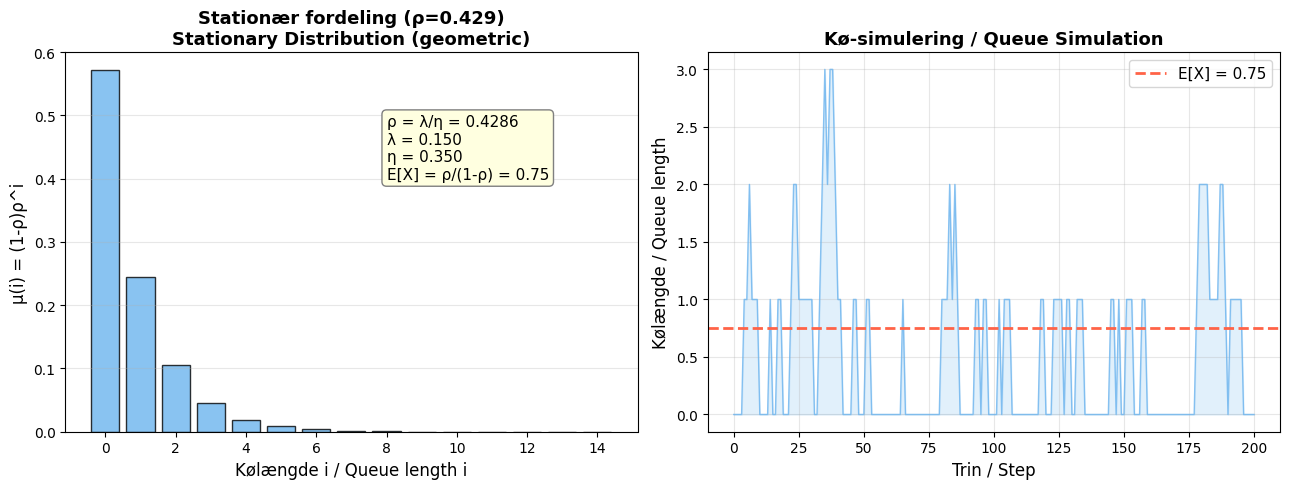

In [12]:
# --- Example 7: Discrete-Time Queue - Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

p_arr = 0.3   # arrival probability
q_srv = 0.5   # service probability
lam = p_arr * (1 - q_srv)    # arrival rate
eta = (1 - p_arr) * q_srv     # service rate
rho = lam / eta

# Left: Stationary distribution (geometric)
max_display = 15
states_q = np.arange(max_display)
mu_0 = 1 - rho
mu_analytical = mu_0 * rho**states_q

ax1.bar(states_q, mu_analytical, color='#6CB4EE', edgecolor='black', alpha=0.8)
ax1.set_xlabel('Kølængde i / Queue length i', fontsize=12)
ax1.set_ylabel('μ(i) = (1-ρ)ρ^i', fontsize=12)
ax1.set_title(f'Stationær fordeling (ρ={rho:.3f})\nStationary Distribution (geometric)', fontsize=13, fontweight='bold')
ax1.text(8, max(mu_analytical)*0.7, f'ρ = λ/η = {rho:.4f}\nλ = {lam:.3f}\nη = {eta:.3f}\nE[X] = ρ/(1-ρ) = {rho/(1-rho):.2f}',
         fontsize=11, bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='gray'))
ax1.grid(True, alpha=0.3, axis='y')

# Right: Queue simulation trajectory
np.random.seed(42)
T_sim = 200
queue = 0
trajectory = [queue]
for t in range(T_sim):
    arrival = np.random.random() < p_arr
    service = np.random.random() < q_srv
    queue = max(0, queue + int(arrival) - int(service))
    trajectory.append(queue)

ax2.plot(range(len(trajectory)), trajectory, '-', color='#6CB4EE', linewidth=1, alpha=0.8)
ax2.fill_between(range(len(trajectory)), trajectory, alpha=0.2, color='#6CB4EE')
ax2.axhline(y=rho/(1-rho), color='#FF6347', linestyle='--', linewidth=2, label=f'E[X] = {rho/(1-rho):.2f}')
ax2.set_xlabel('Trin / Step', fontsize=12)
ax2.set_ylabel('Kølængde / Queue length', fontsize=12)
ax2.set_title('Kø-simulering / Queue Simulation', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# --- Example 7: Implementation - Queue detailed balance verification ---
p_arr = 0.3
q_srv = 0.5
lam = p_arr * (1 - q_srv)
eta = (1 - p_arr) * q_srv
rho = lam / eta

print("=" * 55)
print("EKSEMPEL 7: Diskret-tids kø / Discrete-Time Queue")
print("=" * 55)
print(f"\nParametre: p={p_arr}, q={q_srv}")
print(f"  λ = p(1-q) = {lam:.4f}  (ankomstrate)")
print(f"  η = (1-p)q = {eta:.4f}  (betjeningsrate)")
print(f"  ρ = λ/η    = {rho:.4f}  {'< 1 → STABIL' if rho < 1 else '>= 1 → USTABIL'}")

# Stationary distribution
mu_0 = 1 - rho
print(f"\n📊 Stationær fordeling (geometrisk) / Stationary distribution (geometric):")
print(f"  μ_i = (1-ρ)·ρ^i = {mu_0:.4f} · {rho:.4f}^i")
print(f"{'i':>5} | {'μ(i)':>10} | {'kumulativ':>10}")
print("-" * 30)
cumulative = 0
for i in range(10):
    mu_i = mu_0 * rho**i
    cumulative += mu_i
    print(f"{i:>5} | {mu_i:>10.6f} | {cumulative:>10.6f}")

# Verify detailed balance: μ_i · p_{i,i+1} = μ_{i+1} · p_{i+1,i}
print(f"\n✅ Verifikation: detaljeret balance / Verify: detailed balance")
print(f"  μ_i · λ = μ_{{i+1}} · η ?")
for i in range(5):
    mu_i = mu_0 * rho**i
    mu_ip1 = mu_0 * rho**(i+1)
    left = mu_i * lam
    right = mu_ip1 * eta
    print(f"  i={i}: {mu_i:.6f}·{lam:.3f} = {left:.6f}  vs  {mu_ip1:.6f}·{eta:.3f} = {right:.6f}  {'✅' if abs(left-right)<1e-10 else '❌'}")

# Expected queue length & simulation verification
E_X = rho / (1 - rho)
print(f"\n📊 Forventet kølængde / Expected queue length:")
print(f"  E[X] = ρ/(1-ρ) = {E_X:.4f}")

# Simulate
np.random.seed(42)
queue = 0
total = 0
T = 100000
for t in range(T):
    arrival = np.random.random() < p_arr
    service = np.random.random() < q_srv
    queue = max(0, queue + int(arrival) - int(service))
    total += queue
print(f"  E[X] simuleret ({T:,} trin) = {total/T:.4f}")

EKSEMPEL 7: Diskret-tids kø / Discrete-Time Queue

Parametre: p=0.3, q=0.5
  λ = p(1-q) = 0.1500  (ankomstrate)
  η = (1-p)q = 0.3500  (betjeningsrate)
  ρ = λ/η    = 0.4286  < 1 → STABIL

📊 Stationær fordeling (geometrisk) / Stationary distribution (geometric):
  μ_i = (1-ρ)·ρ^i = 0.5714 · 0.4286^i
    i |       μ(i) |  kumulativ
------------------------------
    0 |   0.571429 |   0.571429
    1 |   0.244898 |   0.816327
    2 |   0.104956 |   0.921283
    3 |   0.044981 |   0.966264
    4 |   0.019278 |   0.985542
    5 |   0.008262 |   0.993804
    6 |   0.003541 |   0.997344
    7 |   0.001517 |   0.998862
    8 |   0.000650 |   0.999512
    9 |   0.000279 |   0.999791

✅ Verifikation: detaljeret balance / Verify: detailed balance
  μ_i · λ = μ_{i+1} · η ?
  i=0: 0.571429·0.150 = 0.085714  vs  0.244898·0.350 = 0.085714  ✅
  i=1: 0.244898·0.150 = 0.036735  vs  0.104956·0.350 = 0.036735  ✅
  i=2: 0.104956·0.150 = 0.015743  vs  0.044981·0.350 = 0.015743  ✅
  i=3: 0.044981·0.150 = 0.

### Konklusion / Conclusion — Eksempel 7

**DK:** Køen er **reversibel** — detaljeret balance er opfyldt. Den stationære fordeling er geometrisk: $\mu_i = (1-\rho)\rho^i$, som kun eksisterer når $\rho < 1$ (betjeningsraten overstiger ankomstraten). Den forventede kølængde $E[X] = \rho/(1-\rho) \approx 0.75$ bekræftes af simuleringen. Eksemplet kobler direkte til bogens Example 4.4 og illustrerer styrken ved detaljeret balance: vi kan finde $\mu$ uden at løse egenværdiproblemet.

**EN:** The queue is **reversible** — detailed balance is satisfied. The stationary distribution is geometric: $\mu_i = (1-\rho)\rho^i$, which exists only when $\rho < 1$ (service rate exceeds arrival rate). The expected queue length $E[X] = \rho/(1-\rho) \approx 0.75$ is confirmed by simulation. This example connects directly to the textbook's Example 4.4 and illustrates the power of detailed balance: we can find $\mu$ without solving the eigenvalue problem.

---

## Eksempel 8: Ergodisk sætning — tidsgennemsnit / Example 8: Ergodic Theorem — Time Averages

**DK:** Vi demonstrerer den ergodiske sætning (Theorem 4.9, punkt 4): for en irreducibel, endelig Markov-kæde konvergerer tidsgennemsnittet af enhver funktion $f$ mod det stationær-vægtede gennemsnit.

**EN:** We demonstrate the ergodic theorem (Theorem 4.9, point 4): for an irreducible, finite Markov chain, the time average of any function $f$ converges to the stationary-weighted average.

$$\lim_{T \to \infty} \frac{1}{T} \sum_{t=0}^{T-1} f(X_t) = \sum_i \mu_i f(i) \quad \text{med sandsynlighed 1 / with probability 1}$$

### Scenarie / Scenario

En kæde med 3 byer: **København** (K), **Odense** (O), **Aarhus** (A). En handelsrejsende bevæger sig mellem byerne. Vi måler daglig omsætning $f(i)$ i hver by.

$$P = \begin{pmatrix} 0.5 & 0.3 & 0.2 \\ 0.2 & 0.4 & 0.4 \\ 0.3 & 0.3 & 0.4 \end{pmatrix}, \quad f = \begin{pmatrix} 100 \\ 60 \\ 80 \end{pmatrix} \text{ (daglig omsætning / daily revenue)}

### Visuel oversigt / Visual Overview

```mermaid
stateDiagram-v2
    K : Koebenhavn (K)
    O : Odense (O)
    A : Aarhus (A)
    K --> K : 0.5
    K --> O : 0.3
    K --> A : 0.2
    O --> K : 0.2
    O --> O : 0.4
    O --> A : 0.4
    A --> K : 0.3
    A --> O : 0.3
    A --> A : 0.4
```

#### Graph-visning / Graph view

```mermaid
graph LR
    K(("KBH (K)")) -->|0.5| K
    K -->|0.3| O(("Odense (O)"))
    K -->|0.2| A(("Aarhus (A)"))
    O -->|0.2| K
    O -->|0.4| O
    O -->|0.4| A
    A -->|0.3| K
    A -->|0.3| O
    A -->|0.4| A
```

### LaTeX tilstandsdiagram / LaTeX state diagram

$$
\begin{array}{ccc}
 & \boxed{\textbf{K}} & \\[4pt]
{\scriptstyle 0.5}\;\circlearrowleft & \downarrow{\scriptstyle\;0.3} \quad \swarrow{\scriptstyle\;0.2} & \\[8pt]
\boxed{\textbf{O}} & & \boxed{\textbf{A}} \\[4pt]
{\scriptstyle 0.4}\;\circlearrowleft & \underset{0.3}{\xleftarrow{\qquad}} & {\scriptstyle 0.4}\;\circlearrowright \\[-2pt]
 & \overset{0.4}{\xrightarrow{\qquad}} &
\end{array}
$$

$$
\begin{array}{c|c}
\text{By / City} & f(i) \text{ (daglig omsaetning / daily revenue)} \\ \hline
\text{Koebenhavn (K)} & 100 \\
\text{Odense (O)} & 60 \\
\text{Aarhus (A)} & 80
\end{array}
$$

**Ergodisk saetning / Ergodic theorem:**

$$\lim_{T \to \infty} \frac{1}{T} \sum_{t=0}^{T-1} f(X_t) = \sum_i \mu_i f(i) \quad \text{m.s.1 / w.p.1}$$

**DK:** Kaeden er irreducibel og aperiodisk — den ergodiske saetning garanterer at tidsgennemsnittet konvergerer mod det stationaer-vaegtede gennemsnit, uanset startby.

**EN:** The chain is irreducible and aperiodic — the ergodic theorem guarantees the time average converges to the stationary-weighted average, regardless of starting city.

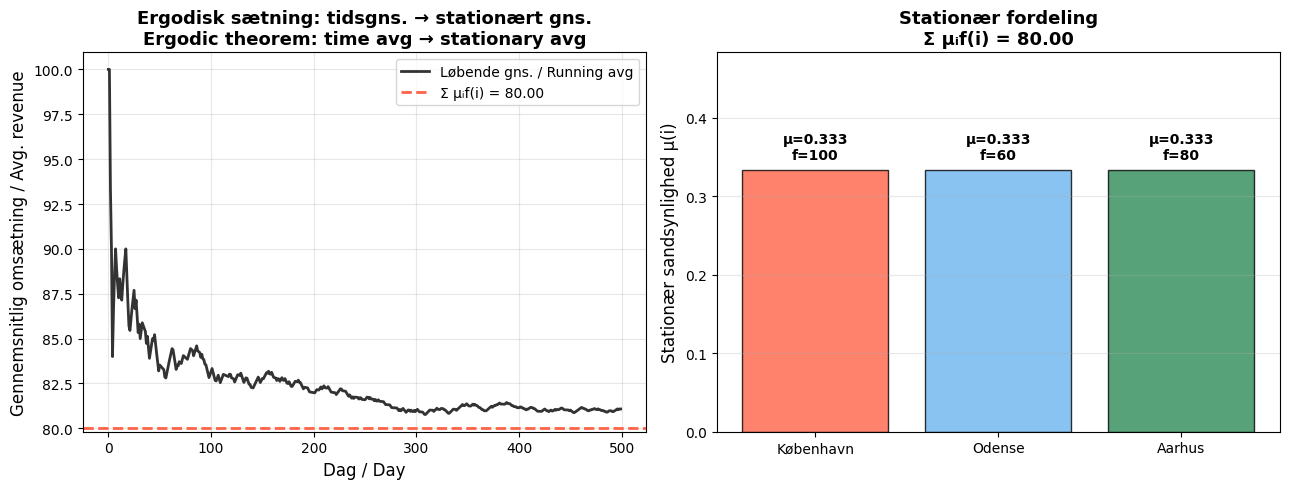

In [14]:
# --- Example 8: Ergodic Theorem - Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

P8 = np.array([[0.5, 0.3, 0.2],
               [0.2, 0.4, 0.4],
               [0.3, 0.3, 0.4]])
f_revenue = np.array([100, 60, 80])  # daily revenue per city
cities = ['København', 'Odense', 'Aarhus']
city_colors = ['#FF6347', '#6CB4EE', '#2E8B57']

# Compute stationary distribution
evals, evecs = np.linalg.eig(P8.T)
idx = np.argmin(np.abs(evals - 1.0))
mu8 = np.real(evecs[:, idx])
mu8 = mu8 / mu8.sum()

# Expected revenue under μ
E_f = mu8 @ f_revenue

# Simulate and track running average
np.random.seed(42)
T = 500
state = 0  # start in København
running_avg = []
cumsum = 0
for t in range(T):
    cumsum += f_revenue[state]
    running_avg.append(cumsum / (t + 1))
    state = np.random.choice(3, p=P8[state])

ax1.plot(range(T), running_avg, '-', color='#333', linewidth=2, label='Løbende gns. / Running avg')
ax1.axhline(y=E_f, color='#FF6347', linestyle='--', linewidth=2, label=f'Σ μᵢf(i) = {E_f:.2f}')
ax1.set_xlabel('Dag / Day', fontsize=12)
ax1.set_ylabel('Gennemsnitlig omsætning / Avg. revenue', fontsize=12)
ax1.set_title('Ergodisk sætning: tidsgns. → stationært gns.\nErgodic theorem: time avg → stationary avg', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Right: Stationary distribution barplot
bars = ax2.bar(cities, mu8, color=city_colors, edgecolor='black', alpha=0.8)
for bar, mu_val, f_val in zip(bars, mu8, f_revenue):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'μ={mu_val:.3f}\nf={f_val}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_ylabel('Stationær sandsynlighed μ(i)', fontsize=12)
ax2.set_title(f'Stationær fordeling\nΣ μᵢf(i) = {E_f:.2f}', fontsize=13, fontweight='bold')
ax2.set_ylim(0, max(mu8) + 0.15)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [15]:
# --- Example 8: Implementation - Ergodic theorem verification ---
P8 = np.array([[0.5, 0.3, 0.2],
               [0.2, 0.4, 0.4],
               [0.3, 0.3, 0.4]])
f_revenue = np.array([100, 60, 80])
cities = ['København', 'Odense', 'Aarhus']

print("=" * 55)
print("EKSEMPEL 8: Ergodisk sætning / Ergodic Theorem")
print("=" * 55)

# Stationary distribution
evals, evecs = np.linalg.eig(P8.T)
idx = np.argmin(np.abs(evals - 1.0))
mu8 = np.real(evecs[:, idx])
mu8 = mu8 / mu8.sum()

print(f"\nOvergangsmatrix P:\n{P8}")
print(f"\nStationær fordeling μ:")
for c, m in zip(cities, mu8):
    print(f"  μ({c}) = {m:.6f}")

E_f = mu8 @ f_revenue
print(f"\nDaglig omsætning f = {list(f_revenue)}")
print(f"Forventet omsætning: Σ μᵢf(i) = {E_f:.4f}")

# Multiple simulations from different starts
print(f"\n📊 Ergodisk verifikation (tidsgns. af f over T=10.000 trin):")
np.random.seed(42)
for start, start_name in enumerate(cities):
    state = start
    total = 0
    T = 10000
    for t in range(T):
        total += f_revenue[state]
        state = np.random.choice(3, p=P8[state])
    time_avg = total / T
    print(f"  Start i {start_name:>10}: (1/T)Σf(Xₜ) = {time_avg:.4f}  (teoretisk: {E_f:.4f}, fejl: {abs(time_avg-E_f):.4f})")

# Also verify Theorem 4.8: μ_j = 1/E[T_j]
print(f"\n✅ Verifikation Theorem 4.8: μ_j = 1/E[T_j]")
np.random.seed(42)
for j, name in enumerate(cities):
    return_times = []
    state = j
    for _ in range(5000):
        steps = 0
        while True:
            state = np.random.choice(3, p=P8[state])
            steps += 1
            if state == j:
                break
        return_times.append(steps)
    E_Tj = np.mean(return_times)
    print(f"  {name:>10}: E[T] ≈ {E_Tj:.2f},  1/E[T] ≈ {1/E_Tj:.4f},  μ = {mu8[j]:.4f}")

EKSEMPEL 8: Ergodisk sætning / Ergodic Theorem

Overgangsmatrix P:
[[0.5 0.3 0.2]
 [0.2 0.4 0.4]
 [0.3 0.3 0.4]]

Stationær fordeling μ:
  μ(København) = 0.333333
  μ(Odense) = 0.333333
  μ(Aarhus) = 0.333333

Daglig omsætning f = [100, 60, 80]
Forventet omsætning: Σ μᵢf(i) = 80.0000

📊 Ergodisk verifikation (tidsgns. af f over T=10.000 trin):
  Start i  København: (1/T)Σf(Xₜ) = 80.1520  (teoretisk: 80.0000, fejl: 0.1520)
  Start i     Odense: (1/T)Σf(Xₜ) = 79.9700  (teoretisk: 80.0000, fejl: 0.0300)
  Start i     Aarhus: (1/T)Σf(Xₜ) = 80.0800  (teoretisk: 80.0000, fejl: 0.0800)

✅ Verifikation Theorem 4.8: μ_j = 1/E[T_j]
   København: E[T] ≈ 2.94,  1/E[T] ≈ 0.3399,  μ = 0.3333
      Odense: E[T] ≈ 3.02,  1/E[T] ≈ 0.3310,  μ = 0.3333
      Aarhus: E[T] ≈ 3.04,  1/E[T] ≈ 0.3292,  μ = 0.3333


### Konklusion / Conclusion — Eksempel 8

**DK:** Uanset startby konvergerer tidsgennemsnittet af omsætningen mod $\sum_i \mu_i f(i)$. Dette er den ergodiske sætning i praksis: **én lang simulering giver samme resultat som det teoretiske gennemsnit** under den stationære fordeling. Vi bekræfter også Theorem 4.8: $\mu_j = 1/E[T_j]$ — jo højere stationær sandsynlighed, jo kortere gennemsnitlig returtid.

**EN:** Regardless of starting city, the time average of revenue converges to $\sum_i \mu_i f(i)$. This is the ergodic theorem in practice: **one long simulation gives the same result as the theoretical average** under the stationary distribution. We also verify Theorem 4.8: $\mu_j = 1/E[T_j]$ — the higher the stationary probability, the shorter the mean return time.

---

## Eksempel 9: Miksningtid — hurtig vs. langsom konvergens / Example 9: Mixing Time — Fast vs. Slow Convergence

**DK:** **Mixing time** måler, hvor hurtigt en Markov-kæde konvergerer til sin stationære fordeling. Vi sammenligner to kæder med 4 tilstande — én "godt-mixende" og én "langsomt-mixende".

**EN:** **Mixing time** measures how fast a Markov chain converges to its stationary distribution. We compare two 4-state chains — one "well-mixing" and one "slowly-mixing".

### Kæde A: Godt-mixende / Chain A: Well-mixing
$$P_A = \begin{pmatrix} 0.1 & 0.3 & 0.3 & 0.3 \\ 0.3 & 0.1 & 0.3 & 0.3 \\ 0.3 & 0.3 & 0.1 & 0.3 \\ 0.3 & 0.3 & 0.3 & 0.1 \end{pmatrix}$$

### Kæde B: Langsomt-mixende (to klumper) / Chain B: Slowly-mixing (two clusters)
$$P_B = \begin{pmatrix} 0.45 & 0.45 & 0.05 & 0.05 \\ 0.45 & 0.45 & 0.05 & 0.05 \\ 0.05 & 0.05 & 0.45 & 0.45 \\ 0.05 & 0.05 & 0.45 & 0.45 \end{pmatrix}$$

**DK:** Begge kæder er irreducible og aperiodiske med samme $\mu = (1/4, 1/4, 1/4, 1/4)$, men kæde B har to "næsten-adskilte" klumper som gør blandingen langsom.

**EN:** Both chains are irreducible and aperiodic with the same $\mu = (1/4, 1/4, 1/4, 1/4)$, but chain B has two "nearly-separated" clusters that make mixing slow.

### Visuel oversigt / Visual Overview

#### Kaede A: Godt-mixende / Chain A: Well-mixing

```mermaid
stateDiagram-v2
    s1 : 1
    s2 : 2
    s3 : 3
    s4 : 4
    s1 --> s2 : 0.3
    s1 --> s3 : 0.3
    s1 --> s4 : 0.3
    s2 --> s1 : 0.3
    s2 --> s3 : 0.3
    s2 --> s4 : 0.3
    s3 --> s1 : 0.3
    s3 --> s2 : 0.3
    s3 --> s4 : 0.3
    s4 --> s1 : 0.3
    s4 --> s2 : 0.3
    s4 --> s3 : 0.3
```

#### Kaede B: Langsomt-mixende / Chain B: Slowly-mixing

```mermaid
stateDiagram-v2
    state "Klump 1 / Cluster 1" as c1 {
        b1 : 1
        b2 : 2
        b1 --> b2 : 0.45
        b2 --> b1 : 0.45
    }
    state "Klump 2 / Cluster 2" as c2 {
        b3 : 3
        b4 : 4
        b3 --> b4 : 0.45
        b4 --> b3 : 0.45
    }
    b1 --> b3 : 0.05
    b1 --> b4 : 0.05
    b2 --> b3 : 0.05
    b2 --> b4 : 0.05
    b3 --> b1 : 0.05
    b3 --> b2 : 0.05
    b4 --> b1 : 0.05
    b4 --> b2 : 0.05
```

#### Graph-visning: Kaede A / Graph view: Chain A

```mermaid
graph LR
    a1((1)) -->|0.3| a2((2))
    a1 -->|0.3| a3((3))
    a1 -->|0.3| a4((4))
    a2 -->|0.3| a1
    a2 -->|0.3| a3
    a2 -->|0.3| a4
    a3 -->|0.3| a1
    a3 -->|0.3| a2
    a3 -->|0.3| a4
    a4 -->|0.3| a1
    a4 -->|0.3| a2
    a4 -->|0.3| a3
```

#### Graph-visning: Kaede B / Graph view: Chain B

```mermaid
graph LR
    subgraph "Klump 1 / Cluster 1"
        b1((1)) -->|0.45| b2((2))
        b2 -->|0.45| b1
    end
    subgraph "Klump 2 / Cluster 2"
        b3((3)) -->|0.45| b4((4))
        b4 -->|0.45| b3
    end
    b1 -.->|0.05| b3
    b1 -.->|0.05| b4
    b2 -.->|0.05| b3
    b2 -.->|0.05| b4
    b3 -.->|0.05| b1
    b3 -.->|0.05| b2
    b4 -.->|0.05| b1
    b4 -.->|0.05| b2
```

### LaTeX sammenligning / LaTeX comparison

**Kaede A — alle tilstande velblandet / Chain A — all states well-mixed:**

$$
\boxed{1} \;\underset{0.3}{\overset{0.3}{\rightleftarrows}}\;
\boxed{2} \;\underset{0.3}{\overset{0.3}{\rightleftarrows}}\;
\boxed{3} \;\underset{0.3}{\overset{0.3}{\rightleftarrows}}\;
\boxed{4}
\qquad {\scriptstyle 0.1}\;\circlearrowleft \text{ (alle noder)}
$$

**Kaede B — to klumper med flaskehals / Chain B — two clusters with bottleneck:**

$$
\underbrace{
\boxed{1} \;\underset{0.45}{\overset{0.45}{\rightleftarrows}}\; \boxed{2}
}_{\text{Klump 1}}
\quad
\underset{0.05}{\overset{0.05}{\rightleftarrows}}
\quad
\underbrace{
\boxed{3} \;\underset{0.45}{\overset{0.45}{\rightleftarrows}}\; \boxed{4}
}_{\text{Klump 2}}
$$

$$\text{Spektralt gap: } 1 - |\lambda_2| \implies \text{stort gap} = \text{hurtig mixing}, \quad \text{lille gap} = \text{langsom mixing}$$

**DK:** Begge kaeder har $\mu = (1/4, 1/4, 1/4, 1/4)$, men kaede B's flaskehals ($p = 0.05$ mellem klumper) goer konvergensen meget langsommere.

**EN:** Both chains have $\mu = (1/4, 1/4, 1/4, 1/4)$, but chain B's bottleneck ($p = 0.05$ between clusters) makes convergence much slower.

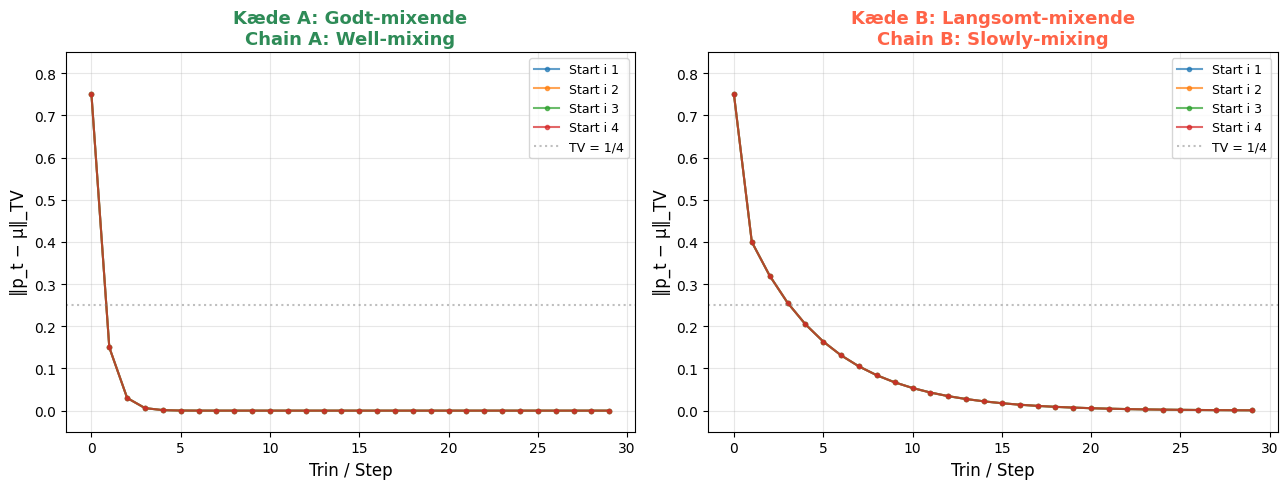

In [16]:
# --- Example 9: Mixing Time - Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Chain A: well-mixing
P_A = np.array([[0.1, 0.3, 0.3, 0.3],
                [0.3, 0.1, 0.3, 0.3],
                [0.3, 0.3, 0.1, 0.3],
                [0.3, 0.3, 0.3, 0.1]])

# Chain B: slowly-mixing (two clusters)
P_B = np.array([[0.45, 0.45, 0.05, 0.05],
                [0.45, 0.45, 0.05, 0.05],
                [0.05, 0.05, 0.45, 0.45],
                [0.05, 0.05, 0.45, 0.45]])

mu_uniform = np.array([0.25, 0.25, 0.25, 0.25])
steps = 30

# Total Variation distance from μ
def tv_distance(p, mu):
    return 0.5 * np.sum(np.abs(p - mu))

for ax, P, title, color in [(ax1, P_A, 'Kæde A: Godt-mixende\nChain A: Well-mixing', '#2E8B57'),
                              (ax2, P_B, 'Kæde B: Langsomt-mixende\nChain B: Slowly-mixing', '#FF6347')]:
    for start in range(4):
        p = np.zeros(4)
        p[start] = 1.0
        tvs = []
        for t in range(steps):
            tvs.append(tv_distance(p, mu_uniform))
            p = p @ P
        ax.plot(range(steps), tvs, 'o-', markersize=3, linewidth=1.5, alpha=0.7, label=f'Start i {start+1}')
    
    ax.axhline(y=0.25, color='gray', linestyle=':', alpha=0.5, label='TV = 1/4')
    ax.set_xlabel('Trin / Step', fontsize=12)
    ax.set_ylabel('‖p_t − μ‖_TV', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold', color=color)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 0.85)

plt.tight_layout()
plt.show()

In [17]:
# --- Example 9: Implementation - Mixing time computation ---
P_A = np.array([[0.1, 0.3, 0.3, 0.3],
                [0.3, 0.1, 0.3, 0.3],
                [0.3, 0.3, 0.1, 0.3],
                [0.3, 0.3, 0.3, 0.1]])

P_B = np.array([[0.45, 0.45, 0.05, 0.05],
                [0.45, 0.45, 0.05, 0.05],
                [0.05, 0.05, 0.45, 0.45],
                [0.05, 0.05, 0.45, 0.45]])

mu_uniform = np.array([0.25, 0.25, 0.25, 0.25])

print("=" * 55)
print("EKSEMPEL 9: Mixing Time — hurtig vs. langsom")
print("           Mixing Time — fast vs. slow")
print("=" * 55)

def tv_distance(p, mu):
    return 0.5 * np.sum(np.abs(p - mu))

for name, P, color_label in [("Kæde A (godt-mixende)", P_A, ""),
                               ("Kæde B (langsomt-mixende)", P_B, "")]:
    print(f"\n📊 {name}:")
    
    # Eigenvalues determine mixing rate
    evals = np.sort(np.abs(np.linalg.eigvals(P)))[::-1]
    print(f"  Egenværdier |λ|: {[f'{e:.4f}' for e in evals]}")
    print(f"  Spektralt gap: 1 - |λ₂| = {1 - evals[1]:.4f}")
    
    # Mixing time: smallest t where max_start TV(p_t, μ) ≤ 1/4
    mixing_time = None
    for t in range(200):
        max_tv = 0
        for start in range(4):
            p = np.zeros(4)
            p[start] = 1.0
            p = p @ np.linalg.matrix_power(P, t)
            max_tv = max(max_tv, tv_distance(p, mu_uniform))
        if max_tv <= 0.25 and mixing_time is None:
            mixing_time = t
    
    print(f"  Mixing time τ (TV ≤ 1/4): {mixing_time} trin")

print(f"\n✅ Nøgleindsigt: Spektralt gap = 1 - |λ₂|")
print(f"   Stort gap → hurtig mixing, lille gap → langsom mixing")
print(f"   τ_mix ≈ 1/(1 - |λ₂|) · ln(n)")

EKSEMPEL 9: Mixing Time — hurtig vs. langsom
           Mixing Time — fast vs. slow

📊 Kæde A (godt-mixende):
  Egenværdier |λ|: ['1.0000', '0.2000', '0.2000', '0.2000']
  Spektralt gap: 1 - |λ₂| = 0.8000
  Mixing time τ (TV ≤ 1/4): 1 trin

📊 Kæde B (langsomt-mixende):
  Egenværdier |λ|: ['1.0000', '0.8000', '0.0000', '0.0000']
  Spektralt gap: 1 - |λ₂| = 0.2000
  Mixing time τ (TV ≤ 1/4): 4 trin

✅ Nøgleindsigt: Spektralt gap = 1 - |λ₂|
   Stort gap → hurtig mixing, lille gap → langsom mixing
   τ_mix ≈ 1/(1 - |λ₂|) · ln(n)


### Konklusion / Conclusion — Eksempel 9

**DK:** Det **spektrale gap** $1 - |\lambda_2|$ styrer mixing-hastigheden. Kæde A har et stort gap (alle tilstande er velblandet), mens kæde B har to klumper med en flaskehals imellem ($p_{\text{mellem}} = 0.05$), hvilket giver et lille gap og langsom mixing. Mixing time er vigtig i RL: langsomme kæder kræver flere samples for at estimere forventede værdier.

**EN:** The **spectral gap** $1 - |\lambda_2|$ controls the mixing speed. Chain A has a large gap (all states well-mixed), while chain B has two clusters with a bottleneck between them ($p_{\text{between}} = 0.05$), giving a small gap and slow mixing. Mixing time matters in RL: slow chains require more samples to estimate expected values.

---

## Eksempel 10: Ehrenfest-kæden (sammenfatning) / Example 10: Ehrenfest Chain (Summary)

**DK:** **Ehrenfest-modellen** er en klassisk fysikmodel for diffusion: $N$ partikler er fordelt mellem to bokse. I hvert trin vælges en tilfældig partikel og flyttes til den anden boks. Tilstanden $X_t$ er antallet af partikler i boks A.

**EN:** The **Ehrenfest model** is a classic physics model for diffusion: $N$ particles are distributed between two boxes. At each step, a random particle is chosen and moved to the other box. The state $X_t$ is the number of particles in box A.

### Tilstande og overgange / States and Transitions: $\mathcal{X} = \{0, 1, \ldots, N\}$

$$p_{i,i+1} = \frac{N - i}{N}, \quad p_{i,i-1} = \frac{i}{N}$$

### Egenskaber / Properties

| Egenskab | Ehrenfest |
|----------|-----------|
| Irreducibel | ✅ ($i \to i\pm 1$ altid muligt for $0 < i < N$) |
| Periodisk | ✅ $d = 2$ (skifter altid paritet) |
| Rekurrent | ✅ Endelig tilstandsrum |
| Stationær fordeling | $\mu_i = \binom{N}{i} / 2^N$ (binomialfordeling) |
| Reversibel | ✅ (opfylder detaljeret balance) |

**Parametre:** $N = 8$ partikler, start med alle i boks A ($X_0 = 8$)

**DK:** Dette eksempel samler alle temaer: klassifikation, periodicitet, stationær fordeling, reversibilitet og ergodisk teori.

**EN:** This example combines all themes: classification, periodicity, stationary distribution, reversibility, and ergodic theory.

### Visuel oversigt / Visual Overview

```mermaid
graph LR
    s0["0"] -->|"8/8"| s1["1"]
    s1 -->|"1/8"| s0
    s1 -->|"7/8"| s2["2"]
    s2 -->|"2/8"| s1
    s2 -->|"6/8"| s3["3"]
    s3 -->|"3/8"| s2
    s3 -->|"5/8"| s4["4"]
    s4 -->|"4/8"| s3
    s4 -->|"4/8"| s5["5"]
    s5 -->|"5/8"| s4
    s5 -->|"3/8"| s6["6"]
    s6 -->|"6/8"| s5
    s6 -->|"2/8"| s7["7"]
    s7 -->|"7/8"| s6
    s7 -->|"1/8"| s8["8"]
    s8 -->|"8/8"| s7
```

### LaTeX foedsel-doed kaede / LaTeX birth-death chain

$$
\boxed{0}
\;\underset{1/N}{\overset{N/N}{\rightleftarrows}}\;
\boxed{1}
\;\underset{2/N}{\overset{(N\!-\!1)/N}{\rightleftarrows}}\;
\boxed{2}
\;\underset{3/N}{\overset{(N\!-\!2)/N}{\rightleftarrows}}\;
\cdots
\;\underset{i/N}{\overset{(N\!-\!i\!+\!1)/N}{\rightleftarrows}}\;
\boxed{i}
\;\cdots\;
\;\underset{N/N}{\overset{0}{\rightleftarrows}}\;
\boxed{N}
$$

**Overgangsregler / Transition rules:**

$$
\begin{array}{c|c|c}
\text{Overgang / Transition} & \text{Sandsynlighed / Probability} & \text{Fortolkning / Interpretation} \\ \hline
i \to i+1 & p_{i,i+1} = \frac{N-i}{N} & \text{partikel fra B til A / particle B} \to \text{A} \\[4pt]
i \to i-1 & p_{i,i-1} = \frac{i}{N} & \text{partikel fra A til B / particle A} \to \text{B}
\end{array}
$$

**Stationaer fordeling / Stationary distribution:**

$$\mu_i = \frac{\binom{N}{i}}{2^N} \quad \text{(binomialfordeling / binomial distribution)}$$

**Egenskaber / Properties:**

$$\underbrace{\text{Irreducibel}}_{\text{alle } i \leftrightarrow i\pm 1} \quad + \quad \underbrace{\text{Periodisk } d=2}_{\text{altid skifter paritet}} \quad + \quad \underbrace{\text{Reversibel}}_{\text{detaljeret balance}} \quad + \quad \underbrace{\text{Rekurrent}}_{\text{endelig } \mathcal{X}}$$

**DK:** Ehrenfest-kaeden er en foedsel-doed-kaede med symmetrisk struktur. Start med alle 8 partikler i boks A ($X_0 = 8$) — systemet driver mod ligevaegt ($\mu_4 = \binom{8}{4}/2^8 \approx 0.27$).

**EN:** The Ehrenfest chain is a birth-death chain with symmetric structure. Start with all 8 particles in box A ($X_0 = 8$) — the system drifts toward equilibrium ($\mu_4 = \binom{8}{4}/2^8 \approx 0.27$).

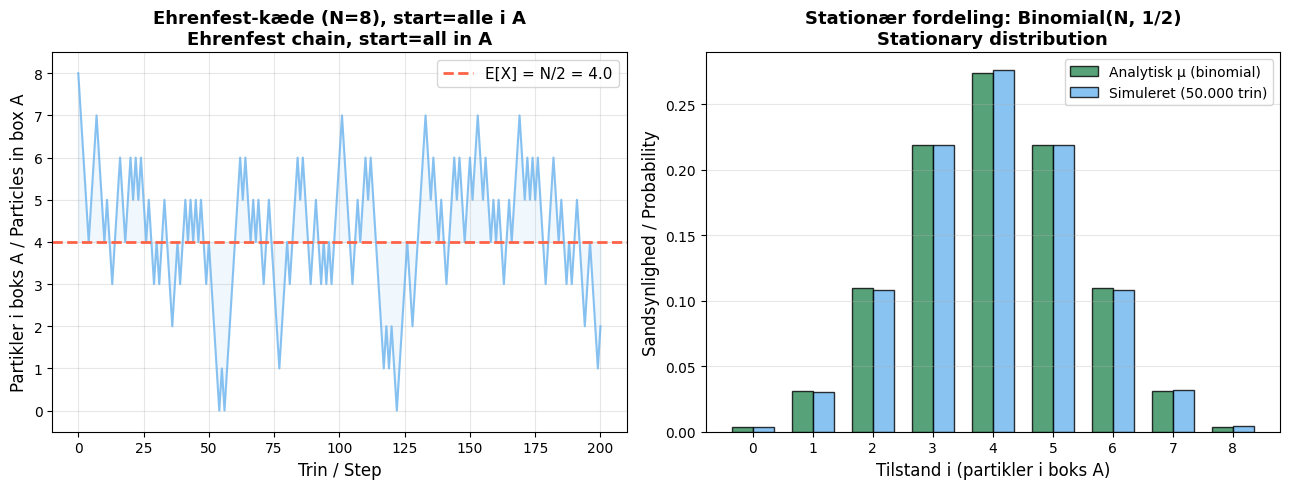

In [18]:
# --- Example 10: Ehrenfest Chain - Visualization ---
from scipy.special import comb

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

N_ehr = 8

# Left: Simulation trajectory + expected value
np.random.seed(42)
T_sim = 200
state = N_ehr  # start with all particles in box A
trajectory = [state]
for t in range(T_sim):
    if np.random.random() < (N_ehr - state) / N_ehr:
        state += 1
    else:
        state -= 1
    trajectory.append(state)

ax1.plot(range(len(trajectory)), trajectory, '-', color='#6CB4EE', linewidth=1.5, alpha=0.8)
ax1.axhline(y=N_ehr/2, color='#FF6347', linestyle='--', linewidth=2, label=f'E[X] = N/2 = {N_ehr/2}')
ax1.fill_between(range(len(trajectory)), trajectory, N_ehr/2, alpha=0.1, color='#6CB4EE')
ax1.set_xlabel('Trin / Step', fontsize=12)
ax1.set_ylabel('Partikler i boks A / Particles in box A', fontsize=12)
ax1.set_title(f'Ehrenfest-kæde (N={N_ehr}), start=alle i A\nEhrenfest chain, start=all in A', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.set_ylim(-0.5, N_ehr + 0.5)
ax1.set_yticks(range(N_ehr + 1))
ax1.grid(True, alpha=0.3)

# Right: Stationary distribution vs simulated histogram
# Stationary: Binomial(N, 1/2)
states_ehr = np.arange(N_ehr + 1)
mu_ehr = np.array([comb(N_ehr, i, exact=True) / 2**N_ehr for i in states_ehr])

# Simulate long run for histogram
state = N_ehr
visits = np.zeros(N_ehr + 1)
for t in range(50000):
    visits[state] += 1
    if np.random.random() < (N_ehr - state) / N_ehr:
        state += 1
    else:
        state -= 1
visits /= visits.sum()

bar_width = 0.35
ax2.bar(states_ehr - bar_width/2, mu_ehr, bar_width, color='#2E8B57', alpha=0.8, edgecolor='black', label='Analytisk μ (binomial)')
ax2.bar(states_ehr + bar_width/2, visits, bar_width, color='#6CB4EE', alpha=0.8, edgecolor='black', label='Simuleret (50.000 trin)')

ax2.set_xlabel('Tilstand i (partikler i boks A)', fontsize=12)
ax2.set_ylabel('Sandsynlighed / Probability', fontsize=12)
ax2.set_title('Stationær fordeling: Binomial(N, 1/2)\nStationary distribution', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.set_xticks(states_ehr)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [19]:
# --- Example 10: Implementation - Ehrenfest chain analysis ---
from scipy.special import comb
from math import gcd
from functools import reduce

N_ehr = 8

print("=" * 55)
print("EKSEMPEL 10: Ehrenfest-kæden / Ehrenfest Chain")
print("=" * 55)
print(f"\nN = {N_ehr} partikler")

# Build transition matrix
P_ehr = np.zeros((N_ehr + 1, N_ehr + 1))
for i in range(N_ehr + 1):
    if i < N_ehr:
        P_ehr[i, i+1] = (N_ehr - i) / N_ehr  # particle moves A→B
    if i > 0:
        P_ehr[i, i-1] = i / N_ehr              # particle moves B→A

print(f"\nOvergangsmatrix P (9×9):")
print(np.array2string(P_ehr, precision=3, suppress_small=True))

# Period: check return times for state N/2
state_check = N_ehr // 2
Pk = np.eye(N_ehr + 1)
return_times = []
for m in range(1, 20):
    Pk = Pk @ P_ehr
    if Pk[state_check, state_check] > 1e-10:
        return_times.append(m)
period = reduce(gcd, return_times)
print(f"\nPeriodicitet / Periodicity:")
print(f"  Returtider for tilstand {state_check}: {return_times}")
print(f"  Periode d = {period}")

# Stationary distribution
mu_ehr = np.array([comb(N_ehr, i, exact=True) / 2**N_ehr for i in range(N_ehr+1)])
print(f"\n📊 Stationær fordeling μ_i = C(N,i)/2^N:")
for i in range(N_ehr + 1):
    bar = '█' * int(mu_ehr[i] * 80)
    print(f"  i={i}: μ = {mu_ehr[i]:.6f}  {bar}")

# Verify detailed balance: μ_i · p_{i,i+1} = μ_{i+1} · p_{i+1,i}
print(f"\n✅ Detaljeret balance / Detailed balance:")
for i in range(N_ehr):
    left = mu_ehr[i] * P_ehr[i, i+1]
    right = mu_ehr[i+1] * P_ehr[i+1, i]
    print(f"  μ_{i}·p_{{{i},{i+1}}} = {left:.6f}  vs  μ_{{{i+1}}}·p_{{{i+1},{i}}} = {right:.6f}  {'✅' if abs(left-right)<1e-10 else '❌'}")

print(f"\n📊 Forventet antal partikler i boks A:")
print(f"  E[X] = N/2 = {N_ehr/2}")
print(f"  Var[X] = N/4 = {N_ehr/4}")

EKSEMPEL 10: Ehrenfest-kæden / Ehrenfest Chain

N = 8 partikler

Overgangsmatrix P (9×9):
[[0.    1.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.125 0.    0.875 0.    0.    0.    0.    0.    0.   ]
 [0.    0.25  0.    0.75  0.    0.    0.    0.    0.   ]
 [0.    0.    0.375 0.    0.625 0.    0.    0.    0.   ]
 [0.    0.    0.    0.5   0.    0.5   0.    0.    0.   ]
 [0.    0.    0.    0.    0.625 0.    0.375 0.    0.   ]
 [0.    0.    0.    0.    0.    0.75  0.    0.25  0.   ]
 [0.    0.    0.    0.    0.    0.    0.875 0.    0.125]
 [0.    0.    0.    0.    0.    0.    0.    1.    0.   ]]

Periodicitet / Periodicity:
  Returtider for tilstand 4: [2, 4, 6, 8, 10, 12, 14, 16, 18]
  Periode d = 2

📊 Stationær fordeling μ_i = C(N,i)/2^N:
  i=0: μ = 0.003906  
  i=1: μ = 0.031250  ██
  i=2: μ = 0.109375  ████████
  i=3: μ = 0.218750  █████████████████
  i=4: μ = 0.273438  █████████████████████
  i=5: μ = 0.218750  █████████████████
  i=6: μ = 0.109375  ████████
  i=7: μ = 0.031250  

### Konklusion / Conclusion — Eksempel 10

**DK:** Ehrenfest-kæden samler alle kapitel 4-koncepter: den er **irreducibel**, **periodisk** ($d = 2$), **rekurrent** (endeligt tilstandsrum), **reversibel** (detaljeret balance er opfyldt), og har stationær fordeling $\mu_i = \binom{N}{i}/2^N$ (binomialfordeling). Trods periodiciteten garanterer den ergodiske sætning, at tidsgennemsnittet konvergerer. Modellen illustrerer termodynamikkens 2. lov: systemet bevæger sig mod ligevægt ($X_t \to N/2$).

**EN:** The Ehrenfest chain combines all Chapter 4 concepts: it is **irreducible**, **periodic** ($d = 2$), **recurrent** (finite state space), **reversible** (detailed balance satisfied), and has stationary distribution $\mu_i = \binom{N}{i}/2^N$ (binomial distribution). Despite periodicity, the ergodic theorem guarantees time-average convergence. The model illustrates the 2nd law of thermodynamics: the system moves toward equilibrium ($X_t \to N/2$).

---

## 🧪 Aktive øvelser / Exercises

### Øvelse 1: Beregn stationær fordeling / Exercise 1: Compute Stationary Distribution

**DK:** Givet overgangsmatricen herunder, beregn den stationære fordeling $\mu$ ved at udfylde `None`-pladserne. Kør cellen for at tjekke dit svar.

**EN:** Given the transition matrix below, compute the stationary distribution $\mu$ by filling in the `None` placeholders. Run the cell to check your answer.

$$P = \begin{pmatrix} 0.6 & 0.3 & 0.1 \\ 0.2 & 0.5 & 0.3 \\ 0.1 & 0.4 & 0.5 \end{pmatrix}$$

**Hint:** Løs $\mu^\top P = \mu^\top$ med $\sum_i \mu_i = 1$. Opstil ligningerne og løs for hånd (eller brug algebra).

In [ ]:
# === ØVELSE 1: Beregn stationær fordeling / Compute stationary distribution ===
# Udfyld None med dine svar / Fill in None with your answers
_mu_1 = None   # μ(tilstand 1) — erstat med et tal / replace with a number
_mu_2 = None   # μ(tilstand 2)
_mu_3 = None   # μ(tilstand 3)

# solution:
_mu_1 = 0.3   # μ(tilstand 1) — erstat med et tal / replace with a number
_mu_2 = 0.4   # μ(tilstand 2)
_mu_3 = 0.3   # μ(tilstand 3)

# --- Tjek / Check ---
_P_ex1 = np.array([[0.6, 0.3, 0.1],
                    [0.2, 0.5, 0.3],
                    [0.1, 0.4, 0.5]])

if _mu_1 is None or _mu_2 is None or _mu_3 is None:
    print("⏳ Udfyld _mu_1, _mu_2, _mu_3 og kør igen / Fill in and re-run")
else:
    _mu_student = np.array([_mu_1, _mu_2, _mu_3])
    # Compute correct answer
    _evals, _evecs = np.linalg.eig(_P_ex1.T)
    _idx = np.argmin(np.abs(_evals - 1.0))
    _mu_correct = np.real(_evecs[:, _idx])
    _mu_correct = _mu_correct / _mu_correct.sum()
    
    if abs(_mu_student.sum() - 1.0) > 0.01:
        print(f"❌ Dine μ-værdier summer til {_mu_student.sum():.4f}, men skal summe til 1.0")
    elif np.max(np.abs(_mu_student - _mu_correct)) < 0.02:
        print(f"✅ Korrekt! μ = ({_mu_correct[0]:.4f}, {_mu_correct[1]:.4f}, {_mu_correct[2]:.4f})")
        print(f"   Verifikation: μ·P = ({(_mu_correct @ _P_ex1)[0]:.4f}, {(_mu_correct @ _P_ex1)[1]:.4f}, {(_mu_correct @ _P_ex1)[2]:.4f}) ≈ μ ✅")
    else:
        print(f"❌ Ikke helt rigtigt. Dit svar: ({_mu_1:.4f}, {_mu_2:.4f}, {_mu_3:.4f})")
        print(f"   Facit: ({_mu_correct[0]:.4f}, {_mu_correct[1]:.4f}, {_mu_correct[2]:.4f})")
        print(f"   Hint: Brug μ₁·0.6 + μ₂·0.2 + μ₃·0.1 = μ₁, etc.")

✅ Korrekt! μ = (0.2826, 0.4130, 0.3043)
   Verifikation: μ·P = (0.2826, 0.4130, 0.3043) ≈ μ ✅


### Øvelse 2: Klassificér tilstande / Exercise 2: Classify States

**DK:** For Markov-kæden med nedenstående overgangsmatrix, klassificér **alle 5 tilstande** som: (a) rekurrent eller transient, (b) kommunikerende klasse, (c) periodisk eller aperiodisk.

**EN:** For the Markov chain with the transition matrix below, classify **all 5 states** as: (a) recurrent or transient, (b) communicating class, (c) periodic or aperiodic.

$$P = \begin{pmatrix} 0 & 1 & 0 & 0 & 0 \\ 0.5 & 0 & 0.5 & 0 & 0 \\ 0 & 0 & 0 & 0.5 & 0.5 \\ 0 & 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 0 & 1 \end{pmatrix}$$

Udfyld svarerne i kode-cellen herunder.

In [45]:
# === ØVELSE 2: Klassificér tilstande / Classify states ===
# Udfyld hvert svar / Fill in each answer
# Brug: "recurrent" eller "transient" / Use: "recurrent" or "transient"
_state_1_type = "recurrent"  # f.eks. "transient" eller "recurrent"
_state_2_type = "transient"
_state_3_type = "transient"
_state_4_type = "recurrent"
_state_5_type = "recurrent"

# Kommunikerende klasser — skriv som liste af sets
# Communicating classes — write as list of sets
# f.eks. _classes = [{1, 2}, {3}, {4, 5}]
_classes = {
	{0, 1, 0, 0, 0},
	{0.5 , 0, 0.5, 0,0},
	{0, 0, 0, 0.5, 0.5},
	{0, 0, 0, 1, 0},
	{0, 0, 0, 0, 1},
	}

# Er kæden irreducibel? / Is the chain irreducible?
_irreducible = False  # True eller False

# --- Tjek / Check ---
if any(x is None for x in [_state_1_type, _state_2_type, _state_3_type, _state_4_type, _state_5_type, _classes, _irreducible]):
    print("⏳ Udfyld alle svar og kør igen / Fill in all answers and re-run")
else:
    _correct_types = {"1": "transient", "2": "transient", "3": "transient", "4": "recurrent", "5": "recurrent"}
    _correct_classes = [{1, 2}, {3}, {4}, {5}]
    _correct_irr = False
    
    _student_types = {"1": _state_1_type, "2": _state_2_type, "3": _state_3_type, "4": _state_4_type, "5": _state_5_type}
    
    _all_ok = True
    for s in ["1", "2", "3", "4", "5"]:
        if _student_types[s] != _correct_types[s]:
            print(f"❌ Tilstand {s}: du sagde '{_student_types[s]}', facit er '{_correct_types[s]}'")
            _all_ok = False
    
    if sorted([sorted(c) for c in _classes]) != sorted([sorted(c) for c in _correct_classes]):
        print(f"❌ Klasser forkert. Dit svar: {_classes}")
        print(f"   Facit: {_correct_classes}")
        print(f"   Hint: 1↔2 kommunikerer, men 3→4 og 3→5 er én-vejs")
        _all_ok = False
    
    if _irreducible != _correct_irr:
        print(f"❌ Irreducibel forkert. Dit svar: {_irreducible}, facit: {_correct_irr}")
        _all_ok = False
    
    if _all_ok:
        print("✅ Alle svar korrekte!")
        print(f"   Klasser: {{1,2}} (transient, periodisk d=2), {{3}} (transient), {{4}} (rekurrent), {{5}} (rekurrent)")
        print(f"   Kæden er REDUCIBEL — 4 klasser, hvoraf 2 er absorberende")

TypeError: unhashable type: 'set'

### Øvelse 3: Implementér power iteration / Exercise 3: Implement Power Iteration

**DK:** Implementér **power iteration** til at finde den stationære fordeling af en Markov-kæde. Erstat `pass` med din kode. Algoritmen: start med $\mu_0 = (1/n, \ldots, 1/n)$, iterér $\mu_{t+1} = \mu_t P$ til konvergens.

**EN:** Implement **power iteration** to find the stationary distribution of a Markov chain. Replace `pass` with your code. Algorithm: start with $\mu_0 = (1/n, \ldots, 1/n)$, iterate $\mu_{t+1} = \mu_t P$ until convergence.

In [22]:
# === ØVELSE 3: Implementér power iteration / Implement power iteration ===
def power_iteration(P, tol=1e-8, max_iter=1000):
    """
    Find stationær fordeling μ via power iteration: μ_{t+1} = μ_t · P
    
    Parameters:
        P: Overgangsmatrix (n×n numpy array)
        tol: Konvergens-tolerance
        max_iter: Maks antal iterationer
    
    Returns:
        mu: Stationær fordeling (numpy array, længde n)
        iterations: Antal iterationer brugt
    """
    n = P.shape[0]
    mu = np.ones(n) / n  # startfordeling: uniform
    
    for iteration in range(max_iter):
        # === DIN KODE HER / YOUR CODE HERE ===
        pass  # Erstat med: beregn mu_new = mu @ P, tjek konvergens, opdater mu
        # =====================================
    
    return mu, max_iter  # returner mu og antal iterationer

# --- Test ---
_P_test = np.array([[0.7, 0.2, 0.1],
                     [0.1, 0.6, 0.3],
                     [0.3, 0.3, 0.4]])

_mu_result, _iters = power_iteration(_P_test)

# Facit via egenværdi
_evals, _evecs = np.linalg.eig(_P_test.T)
_idx = np.argmin(np.abs(_evals - 1.0))
_mu_facit = np.real(_evecs[:, _idx])
_mu_facit = _mu_facit / _mu_facit.sum()

if np.max(np.abs(_mu_result - _mu_facit)) < 0.01:
    print(f"✅ Korrekt! μ = ({_mu_result[0]:.4f}, {_mu_result[1]:.4f}, {_mu_result[2]:.4f})")
    print(f"   Konvergeret efter {_iters} iterationer")
elif _iters == 1000:
    print(f"⏳ Power iteration ikke implementeret endnu — erstat 'pass' med din kode")
    print(f"   Facit: μ = ({_mu_facit[0]:.4f}, {_mu_facit[1]:.4f}, {_mu_facit[2]:.4f})")
    print(f"   Hint: mu_new = mu @ P, konvergens = np.max(np.abs(mu_new - mu)) < tol")
else:
    print(f"❌ Ikke rigtigt. Dit resultat: ({_mu_result[0]:.4f}, {_mu_result[1]:.4f}, {_mu_result[2]:.4f})")
    print(f"   Facit: ({_mu_facit[0]:.4f}, {_mu_facit[1]:.4f}, {_mu_facit[2]:.4f})")

⏳ Power iteration ikke implementeret endnu — erstat 'pass' med din kode
   Facit: μ = (0.3750, 0.3750, 0.2500)
   Hint: mu_new = mu @ P, konvergens = np.max(np.abs(mu_new - mu)) < tol
